In [60]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from upsetplot import UpSet, from_indicators
import numpy as np
from itertools import combinations, chain

In [3]:
#Paths

HLApollo_df = "/home/codingnewt/ESMCBA/HLApollo/HLApollo_data/BM1_test_with-bigmhc.csv"


In [6]:
mega_df = pd.read_csv(HLApollo_df)
mega_df.head()

/tmp/ipykernel_25629/2432430115.py:1: DtypeWarning: Columns (6,7,8,9,10,11,21,23) have mixed types. Specify dtype option on import or set low_memory=False.
  mega_df = pd.read_csv(HLApollo_df)


,allele,peptide,el,split,n_flank,c_flank,mhc_a_1,mhc_a_2,mhc_b_1,mhc_b_2,...,HLAthena,MHCflurry2.0,HLApollo No Ensembling,HLApollo No Pan-Allelic Training,HLApollo No Flanks,HLApollo No Negative Set Switching,FFNN,common_genotype,mixmhcpred2.2,bigmhc
0,A*01:01,AAAAAAAQCR,0,test,ERMAAAAAAA,SPRCAAERRG,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,NaN,NaN,...,24.535336,99.286603,-38.477352,-10.754808,-40.515800,-36.041462,-4.211227,True,54.96120,0.000553
1,A*01:01,AAAAASALP,0,test,FPYPYTYMAA,ATSAAAAAAA,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,NaN,NaN,...,70.002309,99.286603,-35.676414,-10.865457,-41.991300,-17.961332,-4.918590,True,30.44270,0.000822
2,A*01:01,AAAAPGASP,0,test,SARASREGGR,SPGGDAAWSE,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,NaN,NaN,...,77.592480,99.286603,-29.073595,-10.765699,-39.649063,-31.098759,-3.952342,True,42.32890,0.000571
3,A*01:01,AAAAREEDPY,0,test,NLQCFTVRCS,MDTTLKACPP,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,NaN,NaN,...,11.074875,15.160951,-26.758022,-7.968280,-41.382412,-29.037893,-2.904381,True,8.18588,0.052925
4,A*01:01,AAAASSGRPGAAEL,0,test,PGVLAAAAAA,GGGAGAAAVT,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,NaN,NaN,...,NaN,99.286603,-39.053036,-10.769877,-41.738167,-28.035418,-5.241605,True,19.55280,0.001578


In [9]:
pd.set_option('display.max_columns', None)
print(mega_df.columns)
mega_df.head()


Index(['allele', 'peptide', 'el', 'split', 'n_flank', 'c_flank', 'mhc_a_1',
       'mhc_a_2', 'mhc_b_1', 'mhc_b_2', 'mhc_c_1', 'mhc_c_2',
       'Genotype_mhc_I_human_id', 'Peptide_id', 'Protein_ids', 'protein_ids',
       'transcript_ids', 'gene_id', 'gene_symbol', 'n_samples', 'n_studies',
       'Sample_ids', 'sample_names', 'Study_ids', 'study_names',
       'negative_ensembl_id', 'HLApollo', 'NetMHCpan4.1_BA_score',
       'NetMHCpan4.1_EL_score', 'NetMHCpan4.1_BA_rank', 'NetMHCpan4.1_EL_rank',
       'TransPHLA', 'HLAthena_model_type', 'HLAthena_model', 'HLAthena',
       'MHCflurry2.0', 'HLApollo No Ensembling',
       'HLApollo No Pan-Allelic Training', 'HLApollo No Flanks',
       'HLApollo No Negative Set Switching', 'FFNN', 'common_genotype',
       'mixmhcpred2.2', 'bigmhc'],
      dtype='object')


,allele,peptide,el,split,n_flank,c_flank,mhc_a_1,mhc_a_2,mhc_b_1,mhc_b_2,mhc_c_1,mhc_c_2,Genotype_mhc_I_human_id,Peptide_id,Protein_ids,protein_ids,transcript_ids,gene_id,gene_symbol,n_samples,n_studies,Sample_ids,sample_names,Study_ids,study_names,negative_ensembl_id,HLApollo,NetMHCpan4.1_BA_score,NetMHCpan4.1_EL_score,NetMHCpan4.1_BA_rank,NetMHCpan4.1_EL_rank,TransPHLA,HLAthena_model_type,HLAthena_model,HLAthena,MHCflurry2.0,HLApollo No Ensembling,HLApollo No Pan-Allelic Training,HLApollo No Flanks,HLApollo No Negative Set Switching,FFNN,common_genotype,mixmhcpred2.2,bigmhc
0,A*01:01,AAAAAAAQCR,0,test,ERMAAAAAAA,SPRCAAERRG,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,NaN,NaN,NaN,NaN,60,NaN,36727,ENSP00000490600,ENST00000635767,ENSG00000178177,LCORL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-41.609920,-0.0369,-0.0004,39.3509,33.0000,0.0000,specific,MSiC,24.535336,99.286603,-38.477352,-10.754808,-40.515800,-36.041462,-4.211227,True,54.96120,0.000553
1,A*01:01,AAAAASALP,0,test,FPYPYTYMAA,ATSAAAAAAA,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,NaN,NaN,NaN,NaN,60,NaN,14887,ENSP00000240328,ENST00000240328,ENSG00000121068,TBX2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-40.854607,-0.0446,-0.0005,29.5831,28.8333,0.0000,specific,MSiC,70.002309,99.286603,-35.676414,-10.865457,-41.991300,-17.961332,-4.918590,True,30.44270,0.000822
2,A*01:01,AAAAPGASP,0,test,SARASREGGR,SPGGDAAWSE,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,NaN,NaN,NaN,NaN,60,NaN,4253,ENSP00000234420,ENST00000234420,ENSG00000116062,MSH6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-39.544980,-0.0289,-0.0008,53.3228,21.6129,0.0000,specific,MSiC,77.592480,99.286603,-29.073595,-10.765699,-39.649063,-31.098759,-3.952342,True,42.32890,0.000571
3,A*01:01,AAAAREEDPY,0,test,NLQCFTVRCS,MDTTLKACPP,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,NaN,NaN,NaN,NaN,60,NaN,32926,ENSP00000296051,ENST00000296051,ENSG00000163755,HPS3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-34.739647,-0.1913,-0.0495,1.8480,1.9889,0.9614,specific,MSiC,11.074875,15.160951,-26.758022,-7.968280,-41.382412,-29.037893,-2.904381,True,8.18588,0.052925
4,A*01:01,AAAASSGRPGAAEL,0,test,PGVLAAAAAA,GGGAGAAAVT,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY,NaN,NaN,NaN,NaN,60,NaN,854,ENSP00000305244,ENST00000302006,ENSG00000170549,IRX1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-40.952656,-0.0291,-0.0002,53.0043,47.1111,0.0000,NaN,NaN,NaN,99.286603,-39.053036,-10.769877,-41.738167,-28.035418,-5.241605,True,19.55280,0.001578


In [22]:
print(f"Train split: {len(mega_df[mega_df["split"]== "train"])}")
mega_df.shape

Train split: 0


(2053800, 44)

In [24]:
import pandas as pd

# Load the dataframe (assuming the path is correct)
HLApollo_df = "/home/codingnewt/ESMCBA/HLApollo/HLApollo_data/BM1_test_with-bigmhc.csv"
mega_df = pd.read_csv(HLApollo_df)

# Define input columns to keep
input_columns = [
    'allele', 'peptide', 'n_flank', 'c_flank', 
    'mhc_a_1', 'mhc_a_2', 'mhc_b_1', 'mhc_b_2', 'mhc_c_1', 'mhc_c_2',
    'gene_id', 'gene_symbol', 'transcript_ids', 'Protein_ids', 'Peptide_id'
]

# Define BA model columns
ba_model_columns = [
    'allele', 'peptide',  # Identifiers
    'NetMHCpan4.1_BA_score', 'NetMHCpan4.1_BA_rank',  # NetMHCpan4.1_BA
    'MHCflurry2.0',  # MHCflurry2.0
    'mixmhcpred2.2'  # mixmhcpred2.2
]

# Define EL model columns
el_model_columns = [
    'allele', 'peptide',  # Identifiers
    'HLApollo',  # HLApollo
    'NetMHCpan4.1_EL_score', 'NetMHCpan4.1_EL_rank',  # NetMHCpan4.1_EL
    'TransPHLA',  # TransPHLA
    'HLAthena',  # HLAthena
    'FFNN',  # FFNN
    'bigmhc'  # bigmhc
]

# Create input dataframe
input_df = mega_df[input_columns].copy()

# Create BA dataframe
ba_df = mega_df[ba_model_columns].copy()

# Create EL dataframe
el_df = mega_df[el_model_columns].copy()

# Display the first few rows of each dataframe for verification
print("Input Dataframe:")
print(input_df.head())
print("\nBA Model Outputs:")
print(ba_df.head())
print("\nEL Model Outputs:")
print(el_df.head())

# Verify column counts
print(f"\nInput Dataframe Columns ({len(input_df.columns)}): {input_df.columns.tolist()}")
print(f"BA Dataframe Columns ({len(ba_df.columns)}): {ba_df.columns.tolist()}")
print(f"EL Dataframe Columns ({len(el_df.columns)}): {el_df.columns.tolist()}")

/tmp/ipykernel_25629/1693390582.py:5: DtypeWarning: Columns (6,7,8,9,10,11,21,23) have mixed types. Specify dtype option on import or set low_memory=False.
  mega_df = pd.read_csv(HLApollo_df)


Input Dataframe:
    allele         peptide     n_flank     c_flank  \
0  A*01:01      AAAAAAAQCR  ERMAAAAAAA  SPRCAAERRG   
1  A*01:01       AAAAASALP  FPYPYTYMAA  ATSAAAAAAA   
2  A*01:01       AAAAPGASP  SARASREGGR  SPGGDAAWSE   
3  A*01:01      AAAAREEDPY  NLQCFTVRCS  MDTTLKACPP   
4  A*01:01  AAAASSGRPGAAEL  PGVLAAAAAA  GGGAGAAAVT   

                              mhc_a_1                             mhc_a_2  \
0  YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY  YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY   
1  YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY  YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY   
2  YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY  YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY   
3  YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY  YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY   
4  YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY  YFAMYQENMAHTDANTLYIIYRDYTWVARVYRGY   

  mhc_b_1 mhc_b_2 mhc_c_1 mhc_c_2          gene_id gene_symbol  \
0     NaN     NaN     NaN     NaN  ENSG00000178177       LCORL   
1     NaN     NaN     NaN     NaN  ENSG00000121068        TBX2 

## Here we will first work on all of the BA data

### Plan - convert everything into either RANK or Z score to consolidate data
- This will allow easier sue of data when comparing models and creating figures

In [27]:
# Function to compute percentile ranks (lower values = stronger binders)
def compute_percentile_ranks(series, ascending=True):
    # Drop NaN values for ranking
    non_na_series = series.dropna()
    # Compute ranks (method='average' for ties)
    ranks = non_na_series.rank(ascending=ascending, method='average')
    # Convert to percentile ranks (0 to 100, lower rank = stronger binder)
    percentile_ranks = (ranks / len(non_na_series)) * 100
    # Reindex to original series, filling NaN where original had NaN
    return percentile_ranks.reindex(series.index)

# Create a new dataframe for consolidated ranks
consolidated_ranks_df = ba_df[['allele', 'peptide']].copy()

# Add existing rank columns
consolidated_ranks_df['NetMHCpan4.1_BA_rank'] = ba_df['NetMHCpan4.1_BA_rank']
consolidated_ranks_df['MHCflurry2.0_rank'] = ba_df['MHCflurry2.0']  # Assuming MHCflurry2.0 is already a percentile rank

# Compute percentile ranks for score-based outputs
# NetMHCpan4.1_BA_score (IC50, lower is better)
consolidated_ranks_df['NetMHCpan4.1_BA_score_rank'] = compute_percentile_ranks(ba_df['NetMHCpan4.1_BA_score'], ascending=True)
# mixmhcpred2.2 (assuming IC50-like, lower is better)
consolidated_ranks_df['mixmhcpred2.2_rank'] = compute_percentile_ranks(ba_df['mixmhcpred2.2'], ascending=True)

# Placeholder for partner's Fine-tuned ESM BA model (to be updated with actual predictions)
# Example: consolidated_ranks_df['Fine_tuned_ESM_BA_rank'] = compute_percentile_ranks(ba_df['Fine_tuned_ESM_BA'], ascending=True)
# For now, add a column with NaN values
consolidated_ranks_df['Fine_tuned_ESMCBA_rank'] = pd.NA

# Save the consolidated dataframe
# consolidated_ranks_df.to_csv('SOMEPATH/consolidated_ba_ranks.csv', index=False)

# Display the first few rows for verification
print("Consolidated BA Ranks Dataframe:")
print(consolidated_ranks_df.head())

# Verify column counts
print(f"\nColumns ({len(consolidated_ranks_df.columns)}): {consolidated_ranks_df.columns.tolist()}")

Consolidated BA Ranks Dataframe:
    allele         peptide  NetMHCpan4.1_BA_rank  MHCflurry2.0_rank  \
0  A*01:01      AAAAAAAQCR               39.3509          99.286603   
1  A*01:01       AAAAASALP               29.5831          99.286603   
2  A*01:01       AAAAPGASP               53.3228          99.286603   
3  A*01:01      AAAAREEDPY                1.8480          15.160951   
4  A*01:01  AAAASSGRPGAAEL               53.0043          99.286603   

   NetMHCpan4.1_BA_score_rank  mixmhcpred2.2_rank Fine_tuned_ESMCBA_rank  
0                   27.774394           64.896553                   <NA>  
1                   22.228211           40.887917                   <NA>  
2                   36.185753           53.155698                   <NA>  
3                    3.116297           13.842913                   <NA>  
4                   35.925942           28.543027                   <NA>  

Columns (7): ['allele', 'peptide', 'NetMHCpan4.1_BA_rank', 'MHCflurry2.0_rank', 'NetMHCpa

In [28]:
# Missing Values
print("Missing values per column:\n", consolidated_ranks_df.isna().sum())
print("Total missing values:", consolidated_ranks_df.isna().sum().sum())

Missing values per column:
 allele                              0
peptide                             0
NetMHCpan4.1_BA_rank                0
MHCflurry2.0_rank                   1
NetMHCpan4.1_BA_score_rank          0
mixmhcpred2.2_rank             157801
Fine_tuned_ESMCBA_rank        2053800
dtype: int64
Total missing values: 2211602


In [29]:
#Dealing with missing mixmhcpred values


# 1. Check missing values in mixmhcpred2.2 in the original mega_df
print("Missing values in mixmhcpred2.2 (mega_df):", mega_df['mixmhcpred2.2'].isna().sum())
print("Total rows in mega_df:", len(mega_df))
print("Percentage missing:", (mega_df['mixmhcpred2.2'].isna().sum() / len(mega_df)) * 100)

# 2. Verify data type of mixmhcpred2.2
print("\nData type of mixmhcpred2.2:", mega_df['mixmhcpred2.2'].dtype)

# 3. Summarize non-missing mixmhcpred2.2 values
non_missing = mega_df['mixmhcpred2.2'].dropna()
print("\nSummary of non-missing mixmhcpred2.2 values:")
print(non_missing.describe())
print("Sample of non-missing values:", non_missing.head().tolist())

# 4. Check for patterns in missingness by allele
missing_by_allele = mega_df[mega_df['mixmhcpred2.2'].isna()]['allele'].value_counts()
non_missing_by_allele = mega_df[mega_df['mixmhcpred2.2'].notna()]['allele'].value_counts()
print("\nAlleles with missing mixmhcpred2.2 values (top 5):")
print(missing_by_allele.head())
print("\nAlleles with non-missing mixmhcpred2.2 values (top 5):")
print(non_missing_by_allele.head())

# 5. Check for patterns in missingness by peptide length
mega_df['peptide_length'] = mega_df['peptide'].str.len()
missing_by_length = mega_df[mega_df['mixmhcpred2.2'].isna()]['peptide_length'].value_counts()
non_missing_by_length = mega_df[mega_df['mixmhcpred2.2'].notna()]['peptide_length'].value_counts()
print("\nPeptide lengths with missing mixmhcpred2.2 values:")
print(missing_by_length)
print("\nPeptide lengths with non-missing mixmhcpred2.2 values:")
print(non_missing_by_length)

# 6. Compare missingness with other BA models
print("\nMissing values in other BA model columns (mega_df):")
print(mega_df[['NetMHCpan4.1_BA_score', 'NetMHCpan4.1_BA_rank', 'MHCflurry2.0']].isna().sum())

# 7. Sample rows with missing and non-missing mixmhcpred2.2 values
print("\nSample rows with missing mixmhcpred2.2:")
print(mega_df[mega_df['mixmhcpred2.2'].isna()][['allele', 'peptide', 'mixmhcpred2.2']].head())
print("\nSample rows with non-missing mixmhcpred2.2:")
print(mega_df[mega_df['mixmhcpred2.2'].notna()][['allele', 'peptide', 'mixmhcpred2.2']].head())

Missing values in mixmhcpred2.2 (mega_df): 157801
Total rows in mega_df: 2053800
Percentage missing: 7.68336741649625

Data type of mixmhcpred2.2: float64

Summary of non-missing mixmhcpred2.2 values:
count    1.895999e+06
mean     4.233958e+01
std      2.873927e+01
min      1.000000e-03
25%      1.646260e+01
50%      3.921220e+01
75%      6.677265e+01
max      9.988760e+01
Name: mixmhcpred2.2, dtype: float64
Sample of non-missing values: [54.9612, 30.4427, 42.3289, 8.18588, 19.5528]

Alleles with missing mixmhcpred2.2 values (top 5):
allele
B*27:02                                            17500
A*01:01_A*69:01_B*37:01_B*49:01_C*06:02_C*07:01    14600
A*02:52                                            14100
B*81:01                                            13700
A*26:03_B*27:04_C*12:02                            12600
Name: count, dtype: int64

Alleles with non-missing mixmhcpred2.2 values (top 5):
allele
B*27:05    111000
B*57:01     66000
A*29:02     41800
C*08:02     30600
B*57:0

In [30]:
# List unique alleles in the dataset
unique_alleles = mega_df['allele'].unique()
print("Unique alleles in dataset:", len(unique_alleles))
print("Sample alleles:", unique_alleles[:10])

Unique alleles in dataset: 235
Sample alleles: ['A*01:01' 'A*01:01_A*02:01_B*07:02_B*08:01_C*07:01_C*07:02'
 'A*01:01_A*02:01_B*07:02_B*44:03_C*07:02_C*16:01'
 'A*01:01_A*02:01_B*08:01_B*15:01_C*03:04_C*07:01'
 'A*01:01_A*02:01_B*08:01_B*44:02_C*07:01_C*07:04'
 'A*01:01_A*02:01_B*18:01_B*39:24_C*05:01_C*07:01'
 'A*01:01_A*02:01_B*18:01_B*45:01_C*05:01_C*07:01'
 'A*01:01_A*03:01_B*07:02_B*07:06_C*07:02_C*15:05'
 'A*01:01_A*03:01_B*07:02_B*08:01_C*07:01_C*07:02'
 'A*01:01_A*03:01_B*07:02_B*27:05_C*02:02_C*07:01']


In [ ]:
# unsupported alleles from mixmhcpred2. We will drop them

filtered_ranks_df = consolidated_ranks_df.dropna(subset=['mixmhcpred2.2_rank'])

# Count missing values before and after filtering
print("Missing values in consolidated_ranks_df (before filtering):\n", consolidated_ranks_df.isna().sum())
print("Total missing values (before):", consolidated_ranks_df.isna().sum().sum())
print("\nMissing values in filtered_ranks_df (after filtering):\n", filtered_ranks_df.isna().sum())
print("Total missing values (after):", filtered_ranks_df.isna().sum().sum())

# Display row counts
print("\nRows before filtering:", len(consolidated_ranks_df))
print("Rows after filtering:", len(filtered_ranks_df))
print("Rows dropped:", len(consolidated_ranks_df) - len(filtered_ranks_df))

# Save the filtered dataframe
# filtered_ranks_df.to_csv('SOMEPATH/filtered_consolidated_ba_ranks.csv', index=False)

# Display the first few rows for verification
print("\nFiltered BA Ranks Dataframe (first 5 rows):")
print(filtered_ranks_df.head())

# Verify columns
print(f"\nColumns ({len(filtered_ranks_df.columns)}): {filtered_ranks_df.columns.tolist()}")

Missing values in consolidated_ranks_df (before filtering):
 allele                              0
peptide                             0
NetMHCpan4.1_BA_rank                0
MHCflurry2.0_rank                   1
NetMHCpan4.1_BA_score_rank          0
mixmhcpred2.2_rank             157801
Fine_tuned_ESMCBA_rank        2053800
dtype: int64
Total missing values (before): 2211602

Missing values in filtered_ranks_df (after filtering):
 allele                              0
peptide                             0
NetMHCpan4.1_BA_rank                0
MHCflurry2.0_rank                   0
NetMHCpan4.1_BA_score_rank          0
mixmhcpred2.2_rank                  0
Fine_tuned_ESMCBA_rank        1895999
dtype: int64
Total missing values (after): 1895999

Rows before filtering: 2053800
Rows after filtering: 1895999
Rows dropped: 157801

Filtered BA Ranks Dataframe (first 5 rows):
    allele         peptide  NetMHCpan4.1_BA_rank  MHCflurry2.0_rank  \
0  A*01:01      AAAAAAAQCR               39.3509

In [32]:
# Creating new DFs with filtered rows for BOTH BA and EL models to ensure fair analysis
filtered_el_df = el_df.merge(
    filtered_ranks_df[['allele', 'peptide']],
    on=['allele', 'peptide'],
    how='inner'
)

# Step 3: Count missing values in both dataframes
print("Missing values in filtered_ranks_df (BA):\n", filtered_ranks_df.isna().sum())
print("Total missing values (BA):", filtered_ranks_df.isna().sum().sum())
print("\nMissing values in filtered_el_df (EL):\n", filtered_el_df.isna().sum())
print("Total missing values (EL):", filtered_el_df.isna().sum().sum())

# Step 4: Display row counts
print("\nRows in filtered_ranks_df (BA):", len(filtered_ranks_df))
print("Rows in filtered_el_df (EL):", len(filtered_el_df))

# Step 5: Save the filtered dataframes
filtered_ranks_df.to_csv('filtered_consolidated_ba_ranks.csv', index=False)
filtered_el_df.to_csv('filtered_el_outputs.csv', index=False)

# Step 6: Display the first few rows for verification
print("\nFiltered BA Ranks Dataframe (first 5 rows):")
print(filtered_ranks_df.head())
print("\nFiltered EL Dataframe (first 5 rows):")
print(filtered_el_df.head())

# Step 7: Verify columns
print(f"\nBA Columns ({len(filtered_ranks_df.columns)}): {filtered_ranks_df.columns.tolist()}")
print(f"EL Columns ({len(filtered_el_df.columns)}): {filtered_el_df.columns.tolist()}")

Missing values in filtered_ranks_df (BA):
 allele                              0
peptide                             0
NetMHCpan4.1_BA_rank                0
MHCflurry2.0_rank                   0
NetMHCpan4.1_BA_score_rank          0
mixmhcpred2.2_rank                  0
Fine_tuned_ESMCBA_rank        1895999
dtype: int64
Total missing values (BA): 1895999

Missing values in filtered_el_df (EL):
 allele                        0
peptide                       0
HLApollo                      0
NetMHCpan4.1_EL_score         0
NetMHCpan4.1_EL_rank          0
TransPHLA                     0
HLAthena                 847938
FFNN                          0
bigmhc                        0
dtype: int64
Total missing values (EL): 847938

Rows in filtered_ranks_df (BA): 1895999
Rows in filtered_el_df (EL): 1895999

Filtered BA Ranks Dataframe (first 5 rows):
    allele         peptide  NetMHCpan4.1_BA_rank  MHCflurry2.0_rank  \
0  A*01:01      AAAAAAAQCR               39.3509          99.286603   
1 

In [33]:
filtered_ranks_df.head()

,allele,peptide,NetMHCpan4.1_BA_rank,MHCflurry2.0_rank,NetMHCpan4.1_BA_score_rank,mixmhcpred2.2_rank,Fine_tuned_ESMCBA_rank
0,A*01:01,AAAAAAAQCR,39.3509,99.286603,27.774394,64.896553,<NA>
1,A*01:01,AAAAASALP,29.5831,99.286603,22.228211,40.887917,<NA>
2,A*01:01,AAAAPGASP,53.3228,99.286603,36.185753,53.155698,<NA>
3,A*01:01,AAAAREEDPY,1.8480,15.160951,3.116297,13.842913,<NA>
4,A*01:01,AAAASSGRPGAAEL,53.0043,99.286603,35.925942,28.543027,<NA>


In [38]:
filtered_ranks_with_scores = filtered_ranks_df.merge(
    ba_df[['allele', 'peptide', 'NetMHCpan4.1_BA_score', 'mixmhcpred2.2']],
    on=['allele', 'peptide'],
    how='inner'
)

# Verify merge
print("Rows after merge:", len(filtered_ranks_with_scores))
print("Missing values after merge:\n", filtered_ranks_with_scores.isna().sum())

# Function to compute percentile ranks
def compute_percentile_ranks(series, ascending=True):
    non_na_series = series.dropna()
    ranks = non_na_series.rank(ascending=ascending, method='average')
    percentile_ranks = (ranks / len(non_na_series)) * 100
    return percentile_ranks.reindex(series.index)

# Recompute ranks on filtered dataset
filtered_ranks_with_scores['NetMHCpan4.1_BA_score_rank'] = compute_percentile_ranks(
    filtered_ranks_with_scores['NetMHCpan4.1_BA_score'], ascending=True
)
filtered_ranks_with_scores['mixmhcpred2.2_rank'] = compute_percentile_ranks(
    filtered_ranks_with_scores['mixmhcpred2.2'], ascending=True  # Adjust if higher is better
)

# Create updated_ranks_df by merging recomputed ranks
updated_ranks_df = filtered_ranks_df[['allele', 'peptide', 'NetMHCpan4.1_BA_rank', 'MHCflurry2.0_rank', 'Fine_tuned_ESMCBA_rank']].merge(
    filtered_ranks_with_scores[['allele', 'peptide', 'NetMHCpan4.1_BA_score_rank', 'mixmhcpred2.2_rank']],
    on=['allele', 'peptide'],
    how='left'
)

# Count missing values
print("\nMissing values in updated_ranks_df:\n", updated_ranks_df.isna().sum())
print("Total missing values:", updated_ranks_df.isna().sum().sum())

# Display row counts
print("\nRows in updated_ranks_df:", len(updated_ranks_df))

# Summary statistics for ranks
rank_columns = ['NetMHCpan4.1_BA_rank', 'MHCflurry2.0_rank', 'NetMHCpan4.1_BA_score_rank', 'mixmhcpred2.2_rank']
print("\nSummary statistics for rank columns:")
print(updated_ranks_df[rank_columns].describe())

# Save the updated dataframe
updated_ranks_df.to_csv('filtered_consolidated_ba_ranks_updated.csv', index=False)

# Display first few rows
print("\nUpdated BA Ranks Dataframe (first 5 rows):")
print(updated_ranks_df.head())

Rows after merge: 1895999
Missing values after merge:
 allele                              0
peptide                             0
NetMHCpan4.1_BA_rank                0
MHCflurry2.0_rank                   0
NetMHCpan4.1_BA_score_rank          0
mixmhcpred2.2_rank                  0
Fine_tuned_ESMCBA_rank        1895999
NetMHCpan4.1_BA_score               0
mixmhcpred2.2                       0
dtype: int64

Missing values in updated_ranks_df:
 allele                              0
peptide                             0
NetMHCpan4.1_BA_rank                0
MHCflurry2.0_rank                   0
Fine_tuned_ESMCBA_rank        1895999
NetMHCpan4.1_BA_score_rank          0
mixmhcpred2.2_rank                  0
dtype: int64
Total missing values: 1895999

Rows in updated_ranks_df: 1895999

Summary statistics for rank columns:
       NetMHCpan4.1_BA_rank  MHCflurry2.0_rank  NetMHCpan4.1_BA_score_rank  \
count          1.895999e+06       1.895999e+06                1.895999e+06   
mean          

In [40]:

# Use updated_ranks_df
allele_counts = updated_ranks_df['allele'].value_counts()
print("Top 10 alleles by frequency:\n", allele_counts.head(10))
print("\nTotal unique alleles:", len(allele_counts))
updated_ranks_df['peptide_length'] = updated_ranks_df['peptide'].str.len()
length_counts = updated_ranks_df['peptide_length'].value_counts().sort_index()
print("\nPeptide length distribution:\n", length_counts)
print("\nSummary statistics for rank columns:")
print(updated_ranks_df[rank_columns].describe())
top_alleles = allele_counts.head(5).index.tolist()
for allele in top_alleles:
    print(f"\nSample data for allele {allele} (first 5 rows):")
    print(updated_ranks_df[updated_ranks_df['allele'] == allele][['allele', 'peptide'] + rank_columns].head())

Top 10 alleles by frequency:
 allele
B*27:05    111000
B*57:01     66000
A*29:02     41800
C*08:02     30600
B*57:03     30000
B*58:01     29900
B*27:09     28000
B*15:01     26600
C*15:02     26600
B*13:01     26200
Name: count, dtype: int64

Total unique alleles: 211

Peptide length distribution:
 peptide_length
8     257777
9     267333
10    262171
11    261942
12    265345
13    291411
14    290020
Name: count, dtype: int64

Summary statistics for rank columns:
       NetMHCpan4.1_BA_rank  MHCflurry2.0_rank  NetMHCpan4.1_BA_score_rank  \
count          1.895999e+06       1.895999e+06                1.895999e+06   
mean           4.807356e+01       6.354275e+01                5.000003e+01   
std            2.978161e+01       3.795202e+01                2.886746e+01   
min            3.300000e-03       0.000000e+00                5.274264e-05   
25%            2.129895e+01       2.761739e+01                2.502675e+01   
50%            4.767300e+01       6.274467e+01               

/tmp/ipykernel_25629/4240505793.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


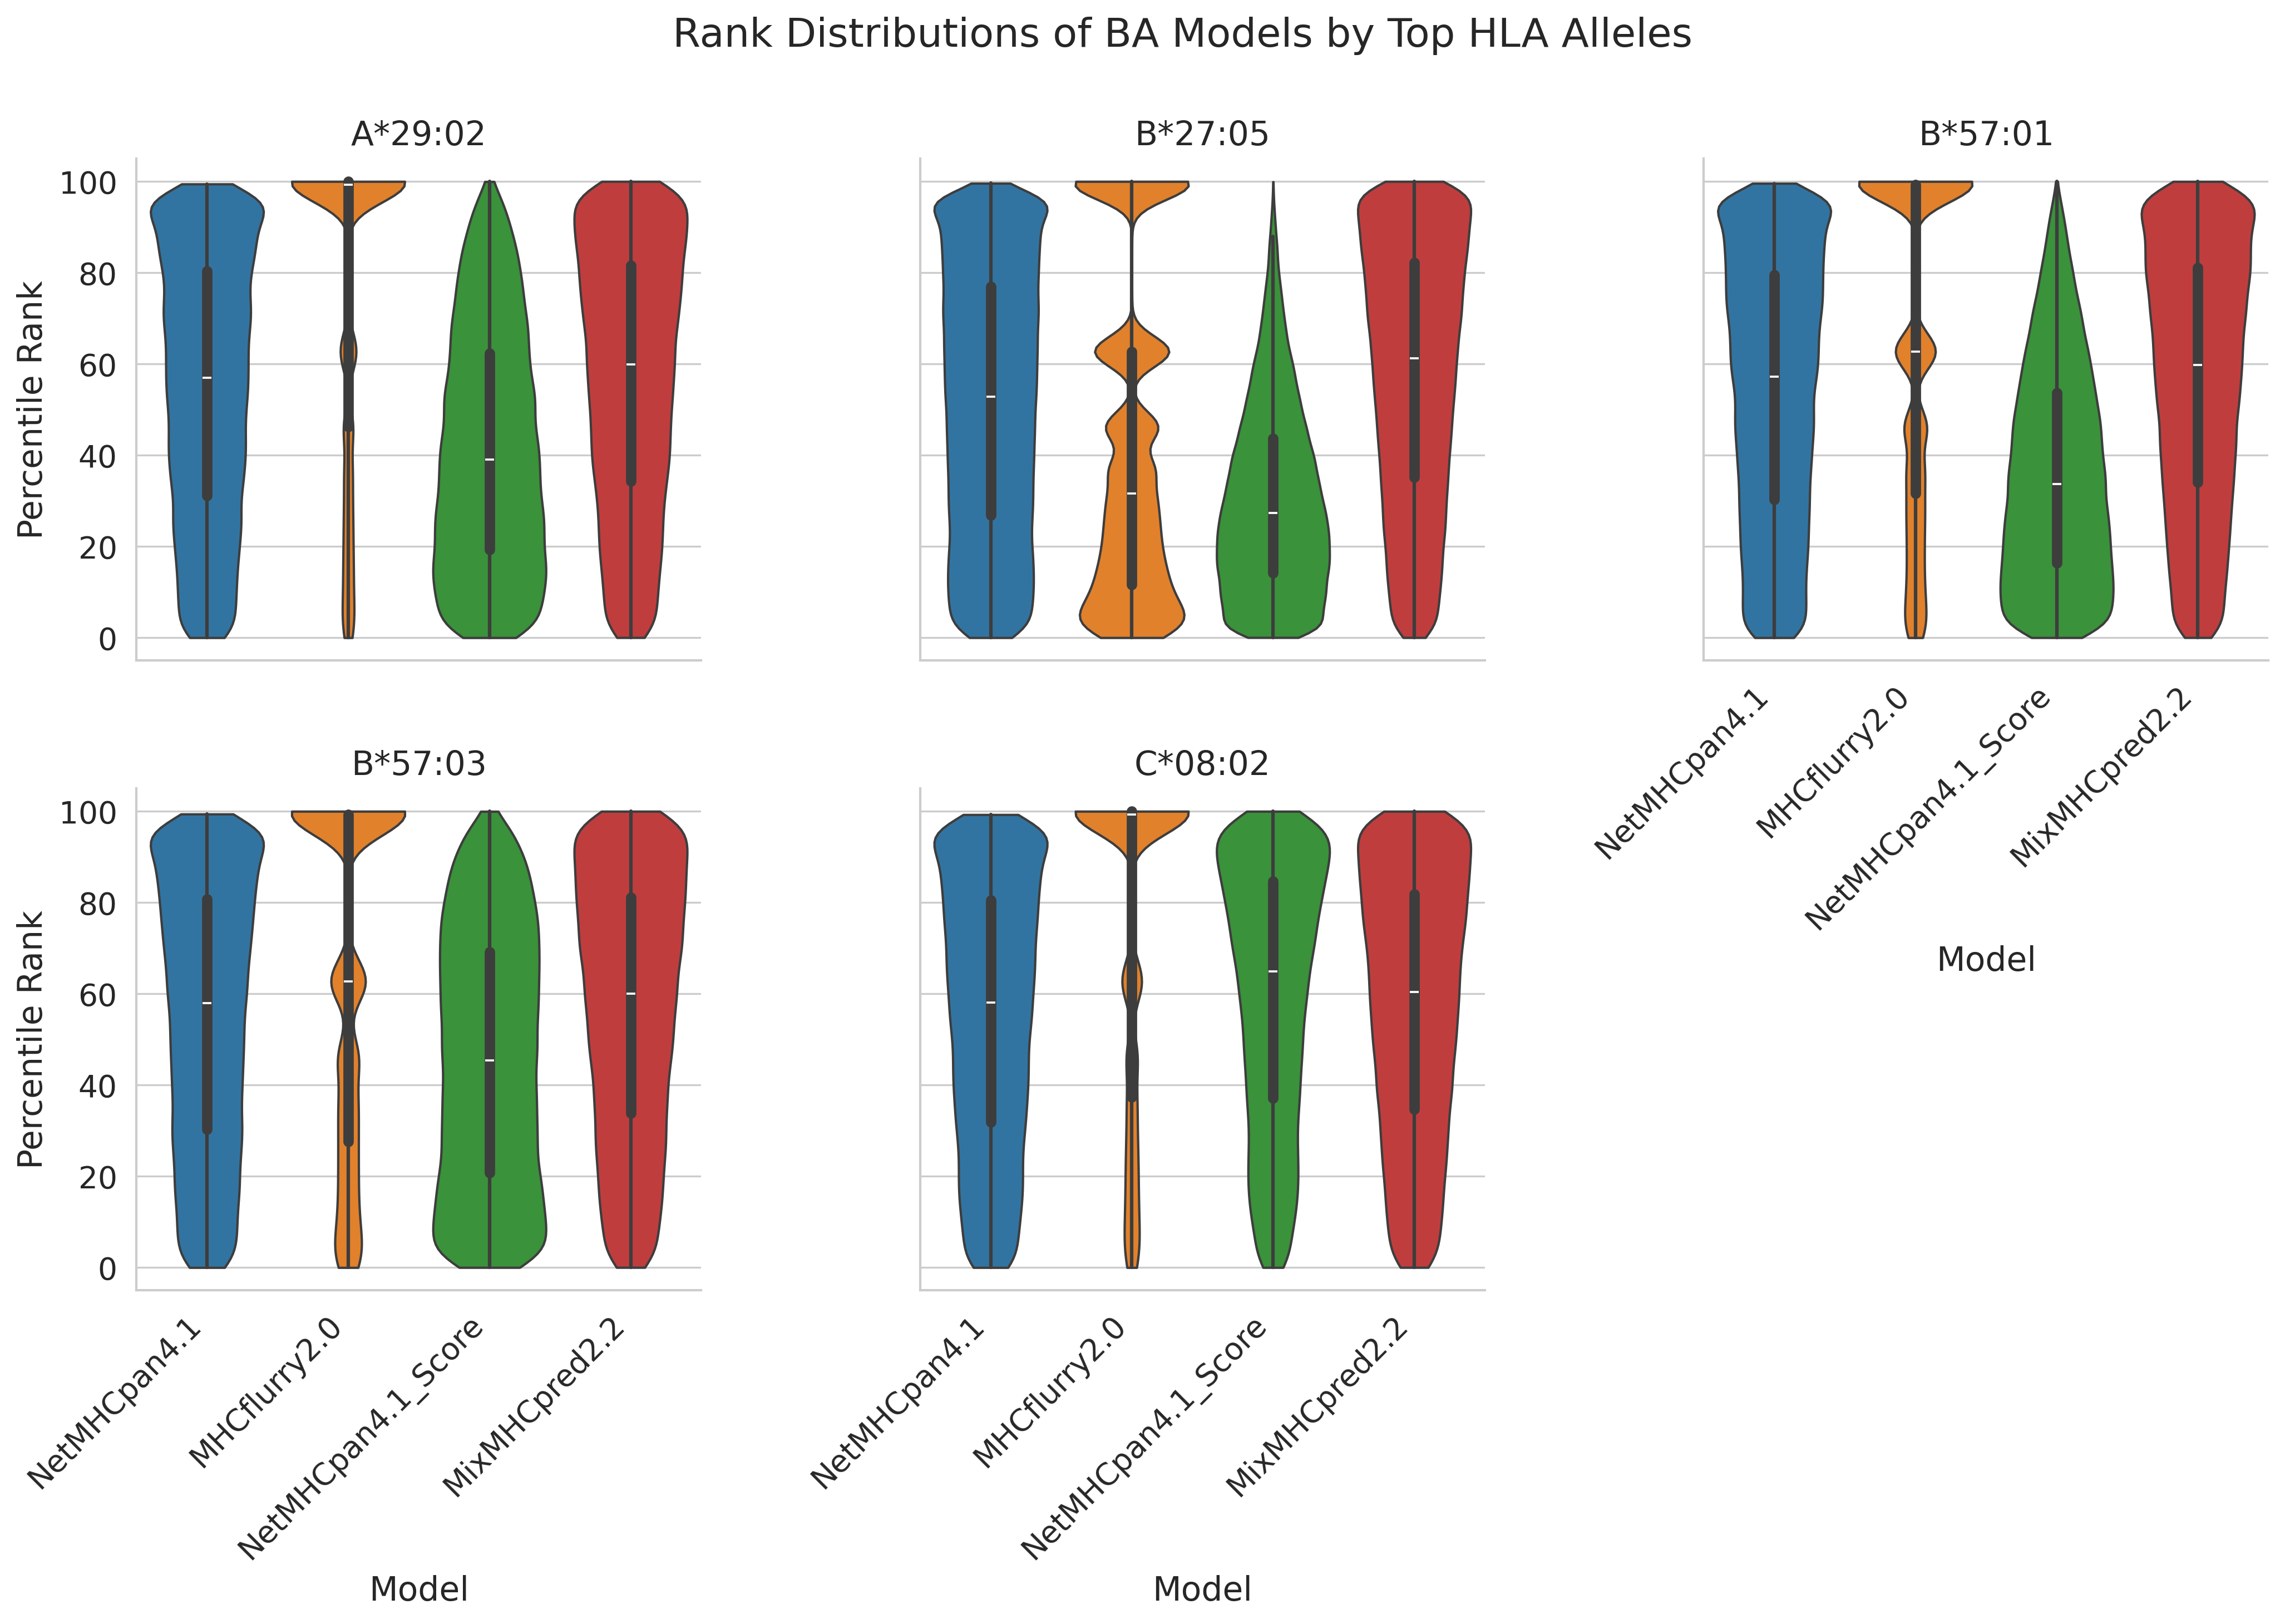


Rank statistics for top alleles:

Allele: B*27:05
       NetMHCpan4.1_BA_rank  MHCflurry2.0_rank  NetMHCpan4.1_BA_score_rank  \
count         111000.000000      111000.000000               111000.000000   
mean              51.657748          41.006206                   30.463195   
std               28.812676          34.097126                   20.381667   
min                0.007400           0.007255                    0.031276   
25%               26.885175          11.630326                   14.210319   
50%               52.865500          31.643179                   27.309350   
75%               76.922200          62.744674                   43.734411   
max               99.594600         100.000000                   99.932542   

       mixmhcpred2.2_rank  
count       111000.000000  
mean            57.730049  
std             28.021251  
min              0.020543  
25%             35.190874  
50%             61.189378  
75%             82.240774  
max             99.999

In [48]:
sns.set(style='whitegrid', context='paper', font_scale=1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# Define rank columns and model names
rank_columns = ['NetMHCpan4.1_BA_rank', 'MHCflurry2.0_rank', 'NetMHCpan4.1_BA_score_rank', 'mixmhcpred2.2_rank']
model_names = ['NetMHCpan4.1', 'MHCflurry2.0', 'NetMHCpan4.1_Score', 'MixMHCpred2.2']
top_alleles = ['B*27:05', 'B*57:01', 'A*29:02', 'C*08:02', 'B*57:03']

# Create violin plots
g = sns.catplot(
    data=updated_ranks_df[updated_ranks_df['allele'].isin(top_alleles)].melt(id_vars=['allele'], value_vars=rank_columns, var_name='Model', value_name='Rank'),
    x='Model', y='Rank', col='allele', kind='violin', col_wrap=3, height=4, aspect=1.2,
    palette='tab10', cut=0  # cut=0 ensures violins don’t extend beyond data range
)
g.set_axis_labels('Model', 'Percentile Rank')
g.set_titles('{col_name}')
g.set_xticklabels(model_names, rotation=45, ha='right')
plt.suptitle('Rank Distributions of BA Models by Top HLA Alleles', y=1.05)
plt.savefig('violin_plots_alleles.png', bbox_inches='tight')
plt.show()

# Print basic statistics for the plotted data
print("\nRank statistics for top alleles:")
for allele in top_alleles:
    print(f"\nAllele: {allele}")
    allele_data = updated_ranks_df[updated_ranks_df['allele'] == allele][rank_columns]
    print(allele_data.describe())

Spearman Correlation Matrix:
                             NetMHCpan4.1_BA_rank  MHCflurry2.0_rank  \
NetMHCpan4.1_BA_rank                    1.000000           0.463138   
MHCflurry2.0_rank                       0.463138           1.000000   
NetMHCpan4.1_BA_score_rank              0.605964           0.282576   
mixmhcpred2.2_rank                      0.628014           0.517654   

                            NetMHCpan4.1_BA_score_rank  mixmhcpred2.2_rank  
NetMHCpan4.1_BA_rank                          0.605964            0.628014  
MHCflurry2.0_rank                             0.282576            0.517654  
NetMHCpan4.1_BA_score_rank                    1.000000            0.271271  
mixmhcpred2.2_rank                            0.271271            1.000000  


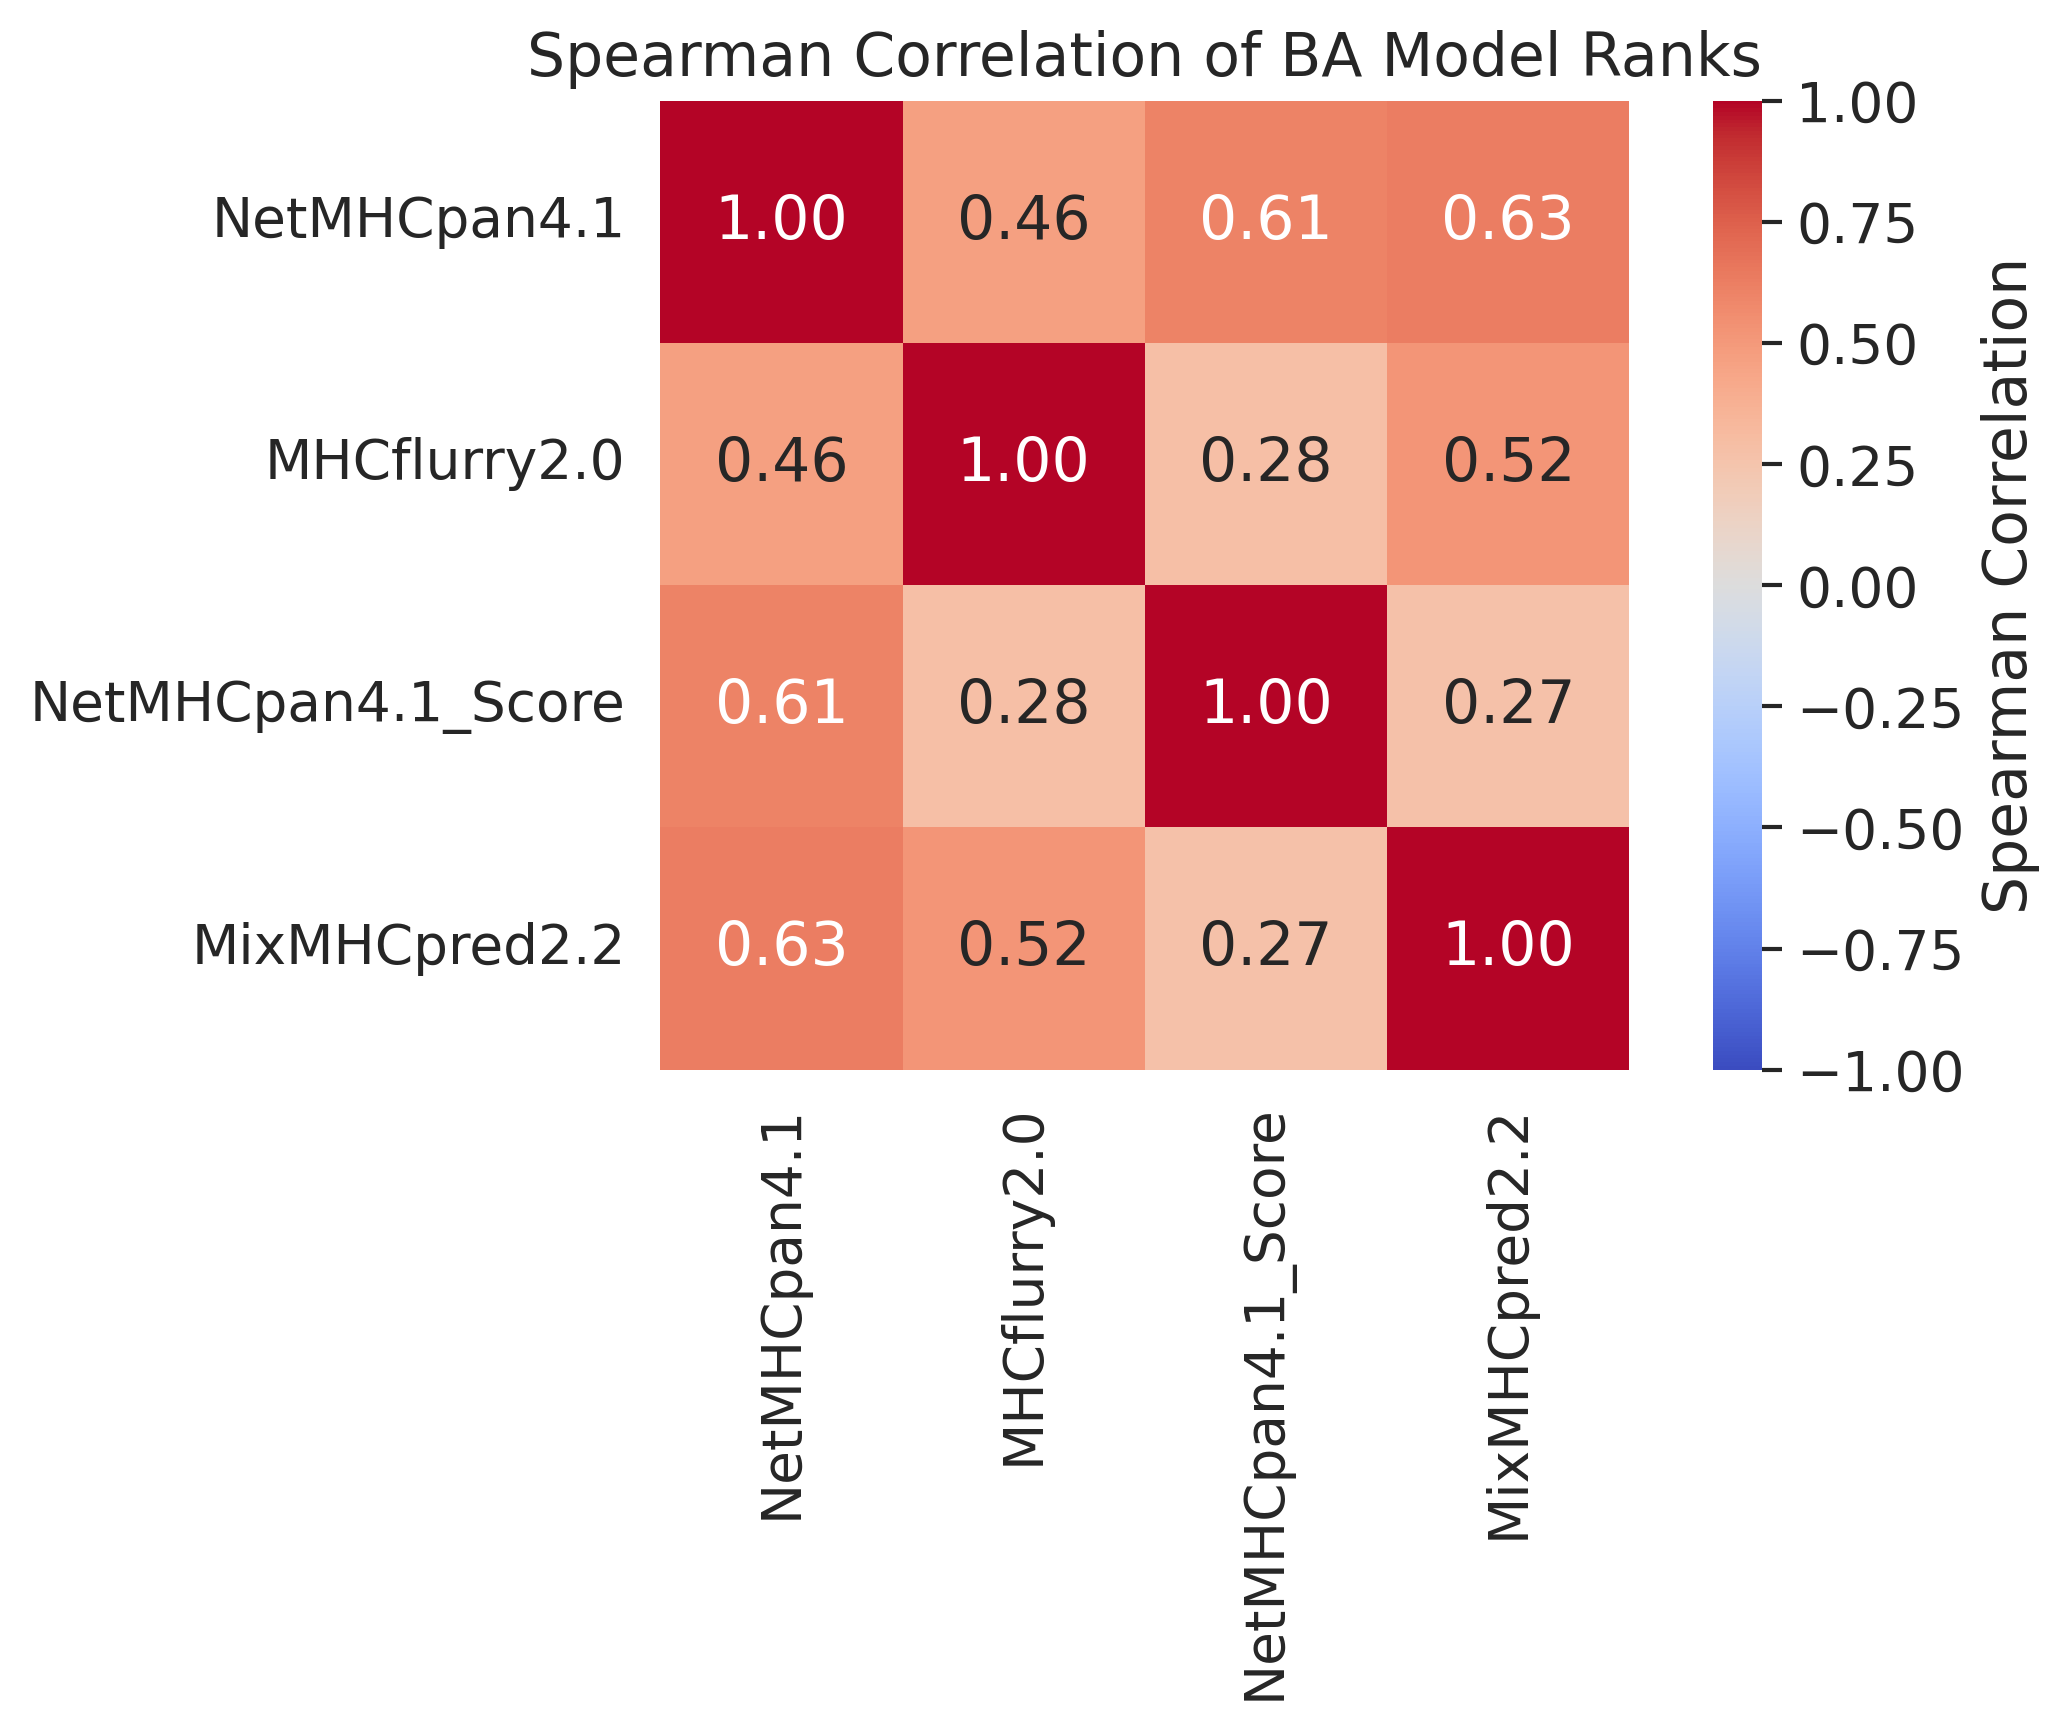

In [49]:
sns.set(style='whitegrid', context='paper', font_scale=1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# Define rank columns and model names
rank_columns = ['NetMHCpan4.1_BA_rank', 'MHCflurry2.0_rank', 'NetMHCpan4.1_BA_score_rank', 'mixmhcpred2.2_rank']
model_names = ['NetMHCpan4.1', 'MHCflurry2.0', 'NetMHCpan4.1_Score', 'MixMHCpred2.2']

# Compute Spearman correlation matrix
corr_matrix = updated_ranks_df[rank_columns].corr(method='spearman')

# Print correlation matrix for reference
print("Spearman Correlation Matrix:\n", corr_matrix)

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,  # Show correlation values
    cmap='coolwarm',  # Red-blue colormap
    vmin=-1, vmax=1, center=0,  # Scale from -1 to 1
    fmt='.2f',  # 2 decimal places
    xticklabels=model_names,
    yticklabels=model_names,
    square=True,  # Square cells
    cbar_kws={'label': 'Spearman Correlation'}
)
plt.title('Spearman Correlation of BA Model Ranks')
plt.tight_layout()
plt.savefig('spearman_heatmap.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_25629/793512650.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


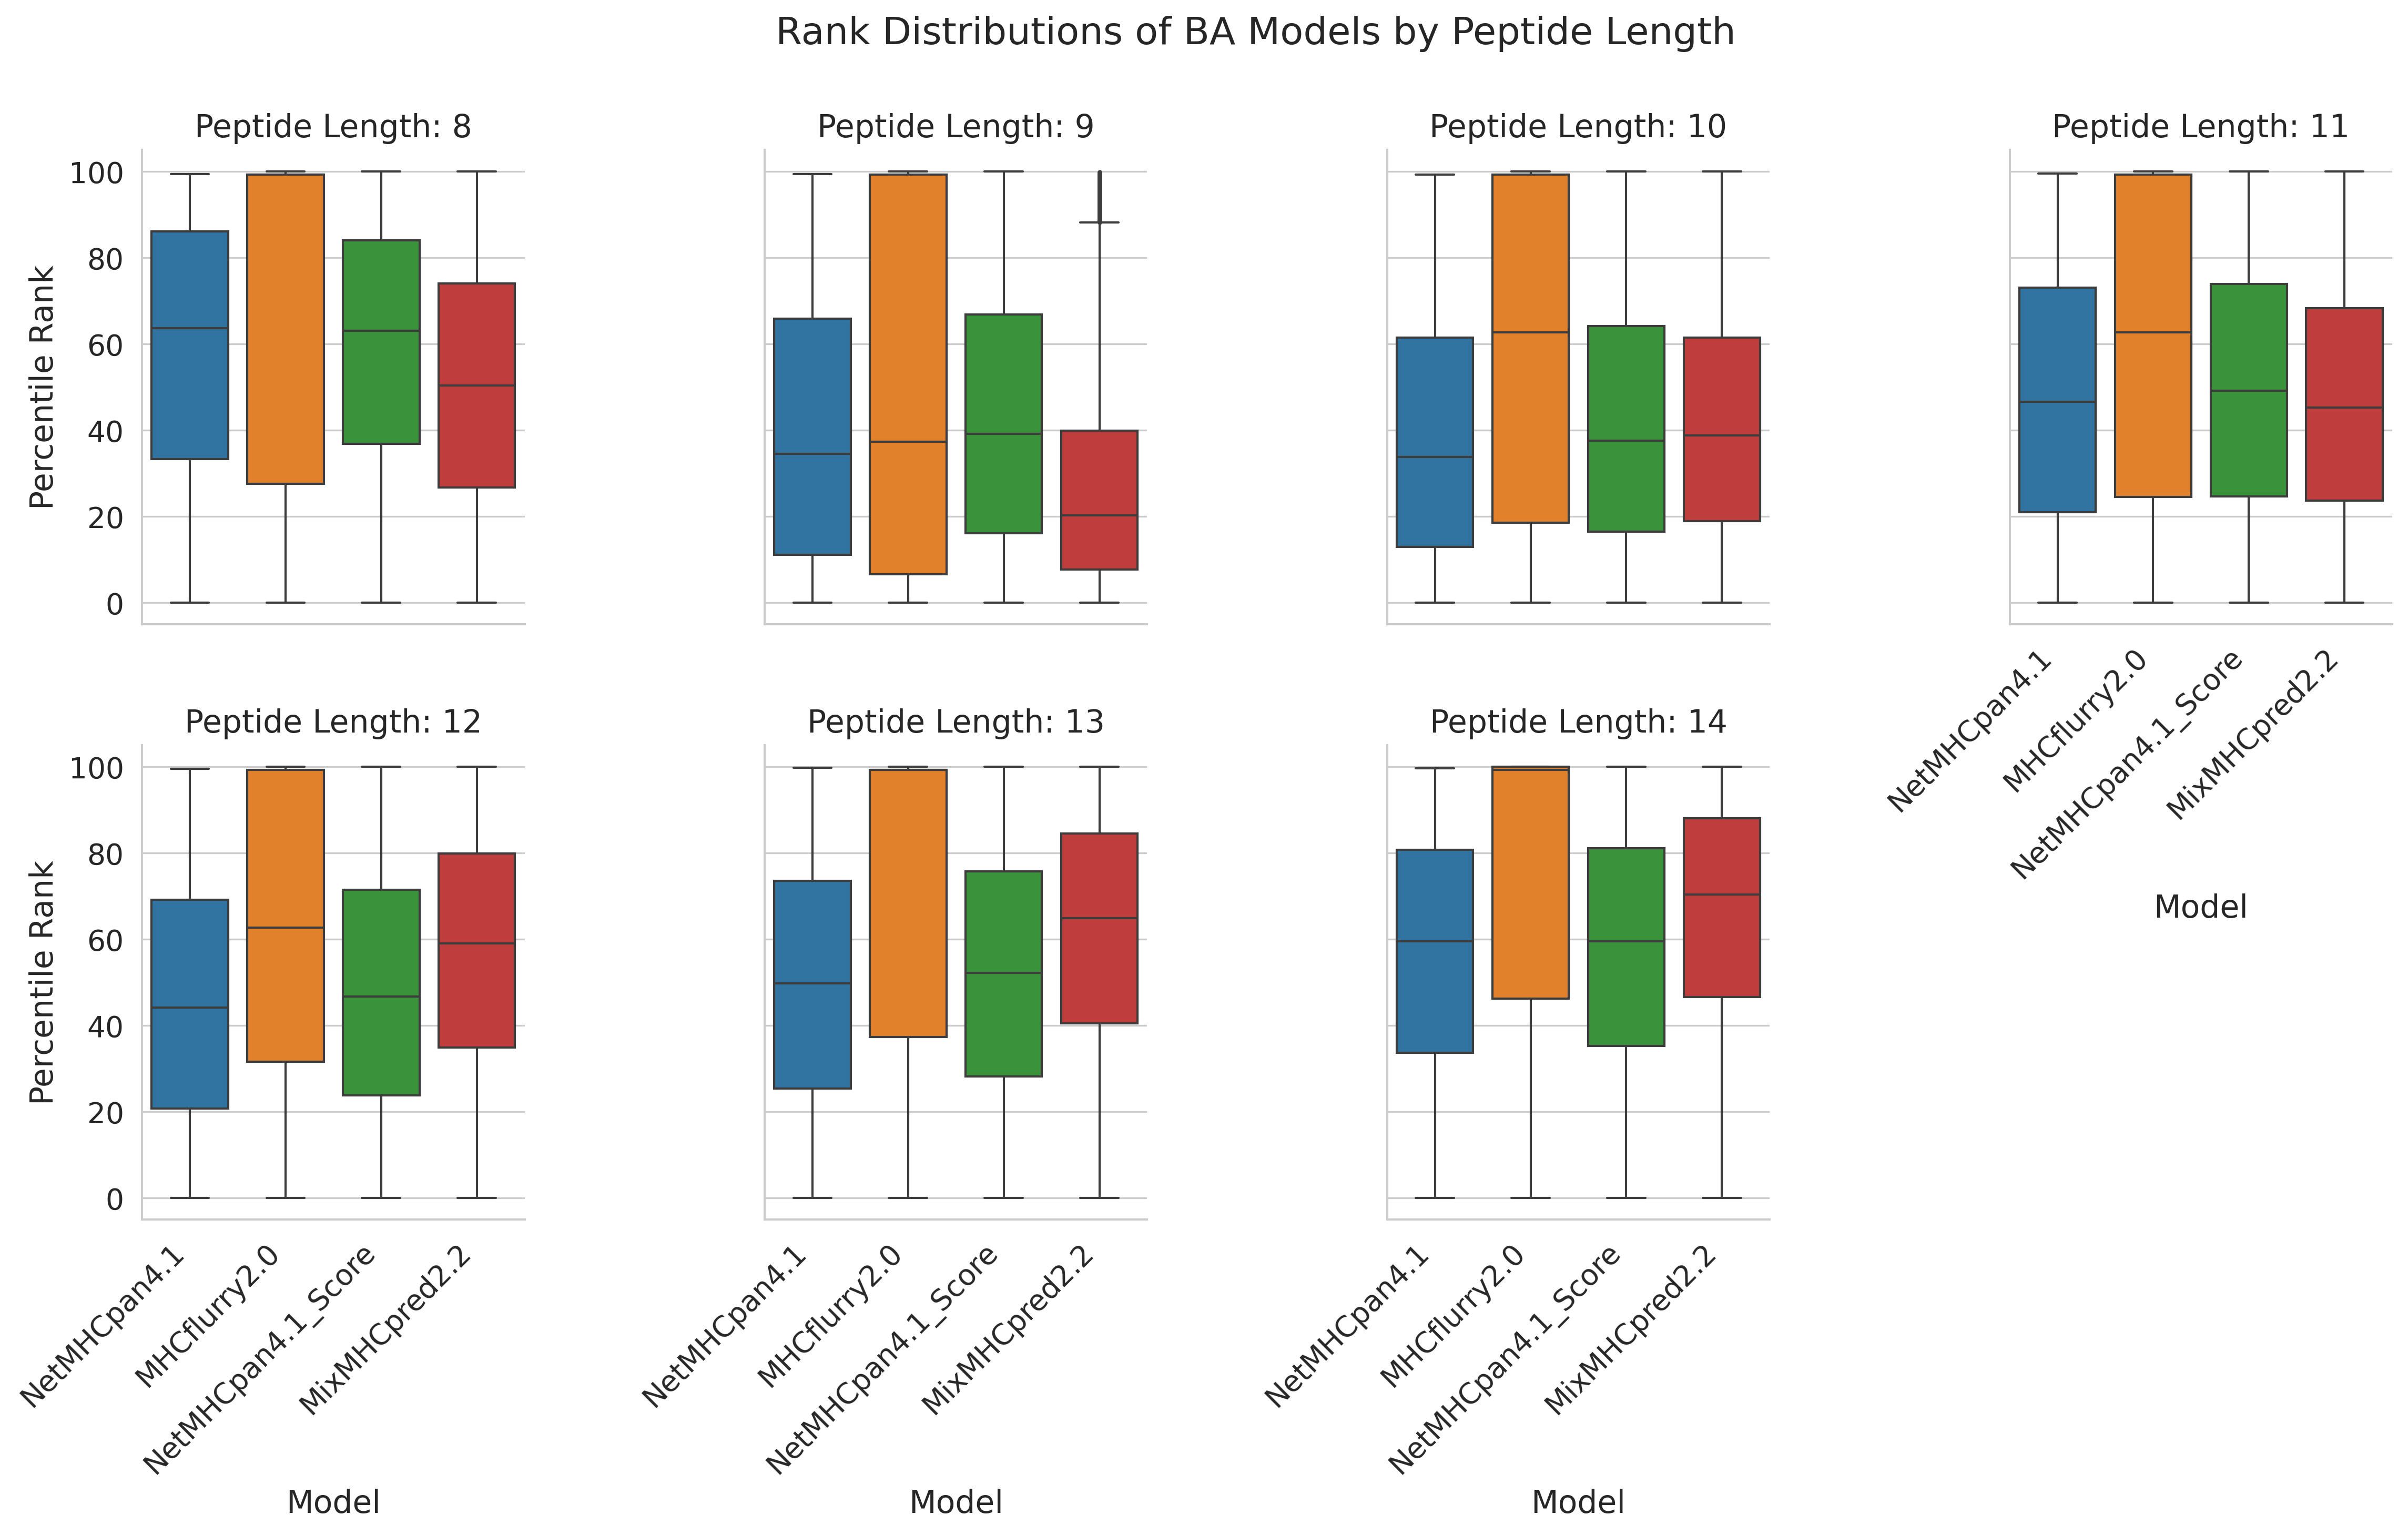

In [54]:
sns.set(style='whitegrid', context='paper', font_scale=1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# Define rank columns and model names
rank_columns = ['NetMHCpan4.1_BA_rank', 'MHCflurry2.0_rank', 'NetMHCpan4.1_BA_score_rank', 'mixmhcpred2.2_rank']
model_names = ['NetMHCpan4.1', 'MHCflurry2.0', 'NetMHCpan4.1_Score', 'MixMHCpred2.2']

# Create box plots by peptide length
g = sns.catplot(
    data=updated_ranks_df.melt(id_vars=['peptide_length'], value_vars=rank_columns, var_name='Model', value_name='Rank'),
    x='Model', y='Rank', col='peptide_length', col_wrap=4, kind='box', height=4, aspect=1,
    palette='tab10', fliersize=1, linewidth=1
)
g.set_axis_labels('Model', 'Percentile Rank')
g.set_titles('Peptide Length: {col_name}')
g.set_xticklabels(model_names, rotation=45, ha='right')
plt.suptitle('Rank Distributions of BA Models by Peptide Length', y=1.05)
plt.savefig('rank_by_peptide_length.png', bbox_inches='tight')
plt.show()


/tmp/ipykernel_25629/2654704323.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=intersection_df, x='Count', y='Intersection', palette='tab10')


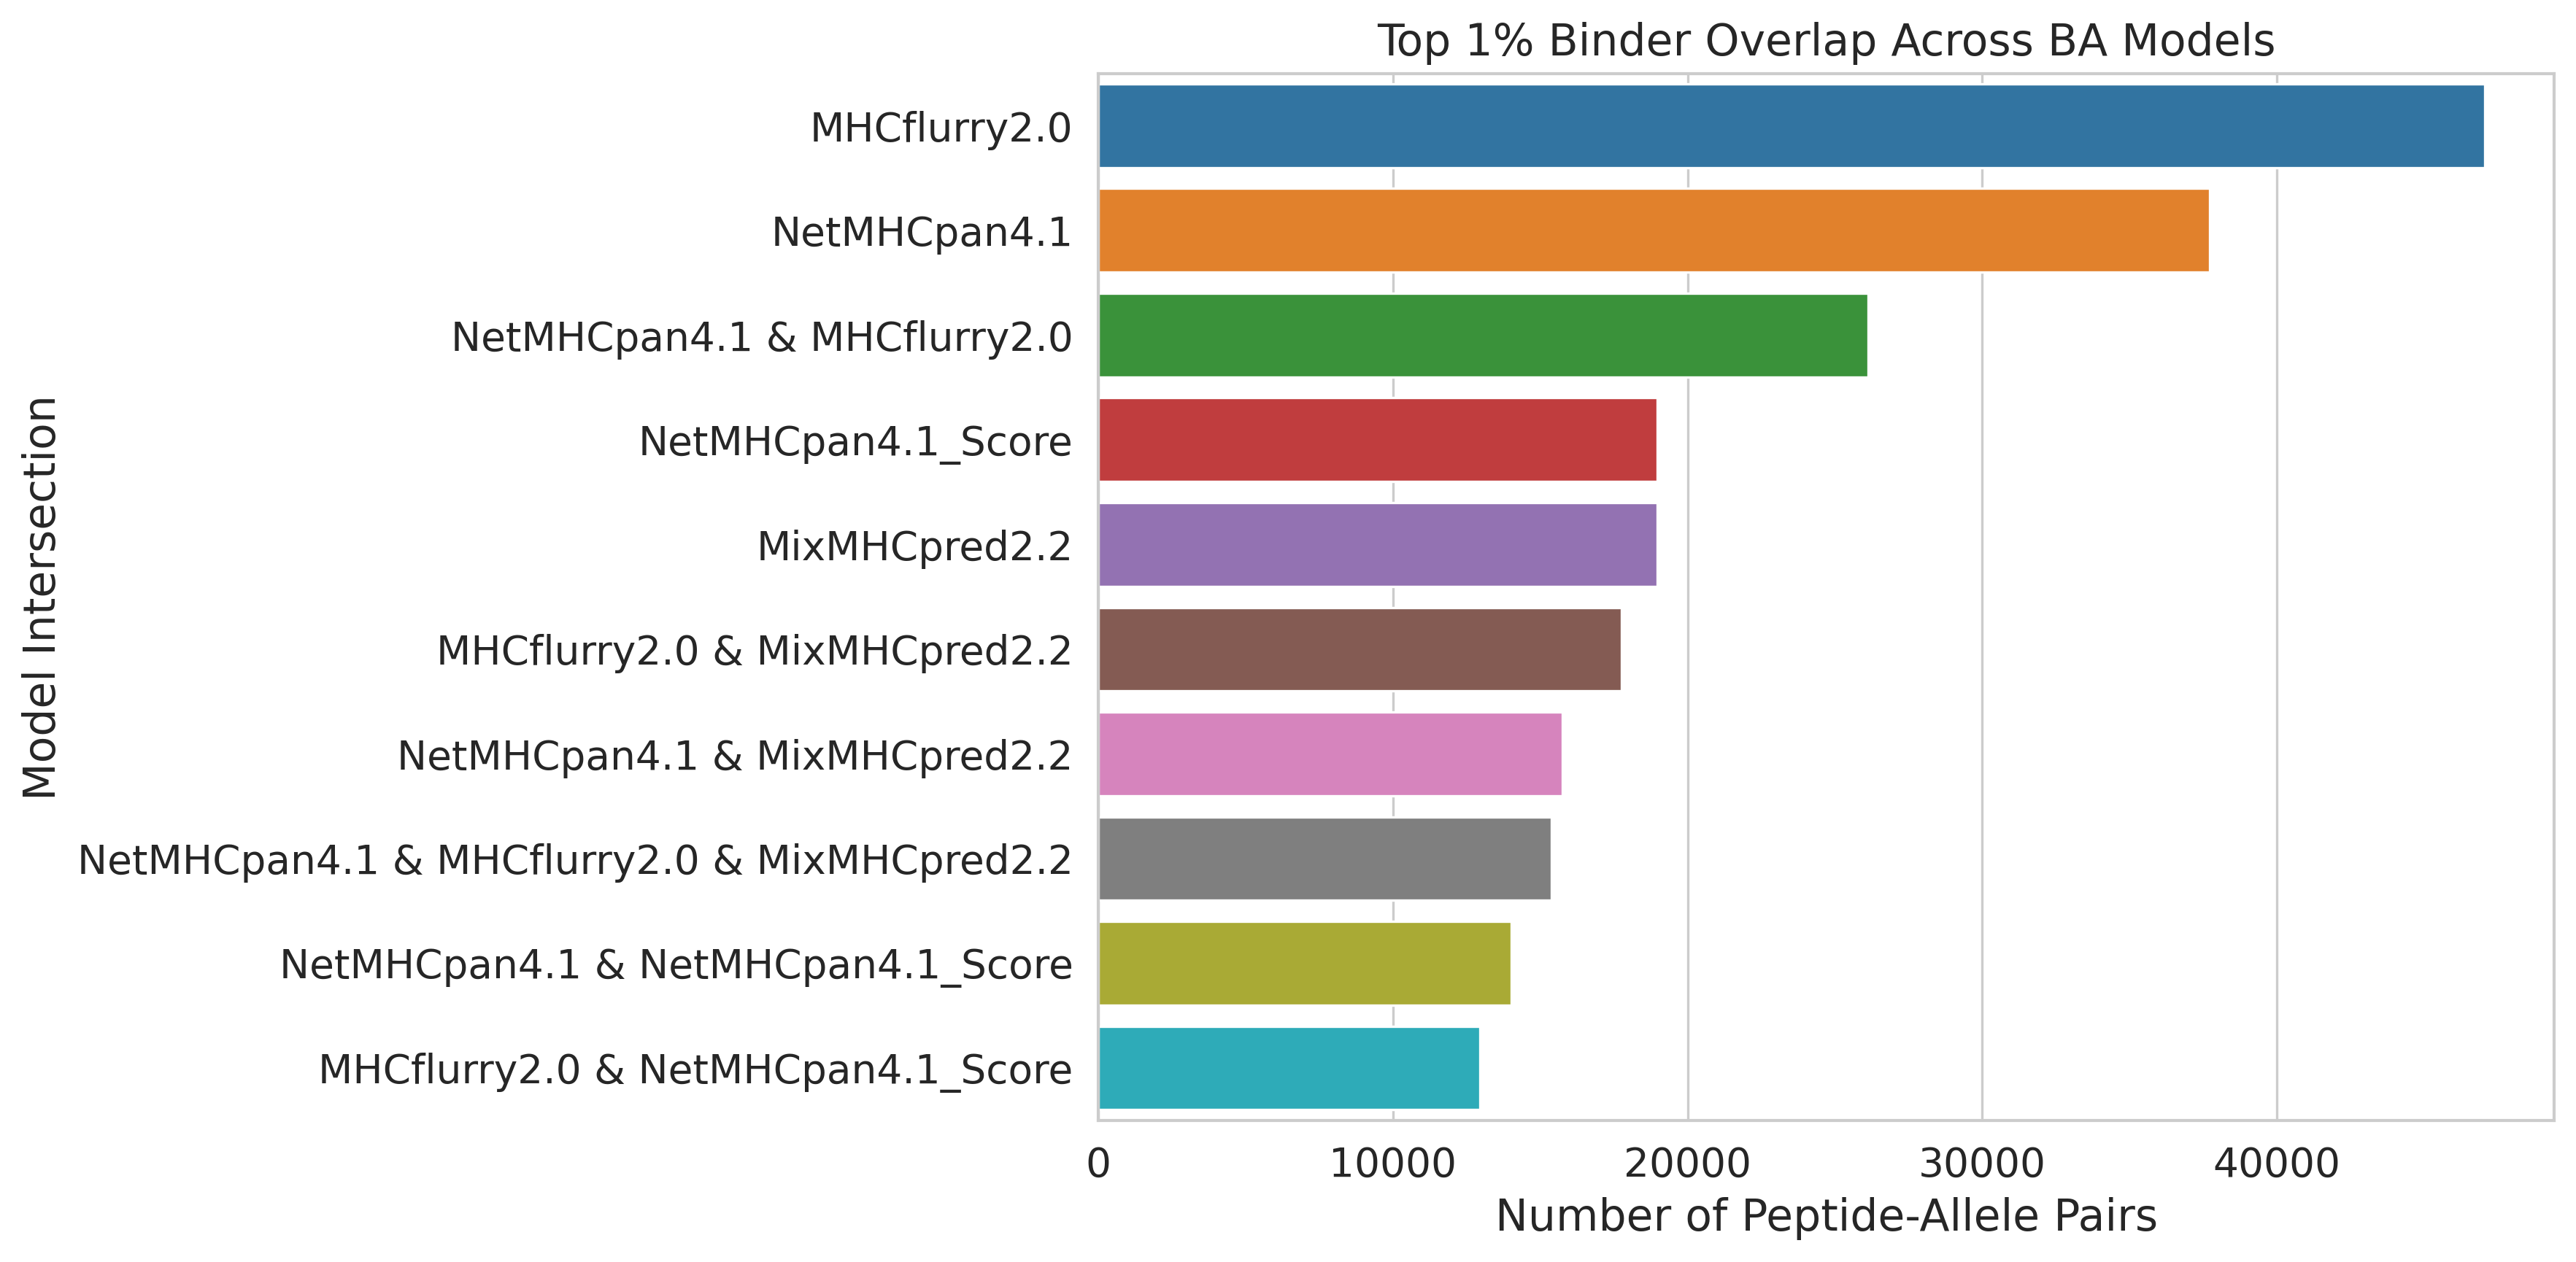


Jaccard Similarity for Top 1% Binders:
                     NetMHCpan4.1  MHCflurry2.0  NetMHCpan4.1_Score  \
NetMHCpan4.1            1.000000      0.445173            0.328288   
MHCflurry2.0            0.445173      1.000000            0.244117   
NetMHCpan4.1_Score      0.328288      0.244117            1.000000   
MixMHCpred2.2           0.384638      0.368127            0.293115   

                    MixMHCpred2.2  
NetMHCpan4.1             0.384638  
MHCflurry2.0             0.368127  
NetMHCpan4.1_Score       0.293115  
MixMHCpred2.2            1.000000  

Top 10 Intersection Counts:
                                    Intersection  Count
1                                  MHCflurry2.0  47075
0                                  NetMHCpan4.1  37735
4                   NetMHCpan4.1 & MHCflurry2.0  26125
2                            NetMHCpan4.1_Score  18959
3                                 MixMHCpred2.2  18959
8                  MHCflurry2.0 & MixMHCpred2.2  17768
6            

In [67]:
sns.set(style='whitegrid', context='paper', font_scale=1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# Define rank columns and model names
rank_columns = ['NetMHCpan4.1_BA_rank', 'MHCflurry2.0_rank', 'NetMHCpan4.1_BA_score_rank', 'mixmhcpred2.2_rank']
model_names = ['NetMHCpan4.1', 'MHCflurry2.0', 'NetMHCpan4.1_Score', 'MixMHCpred2.2']

# Identify top 1% binders (rank < 1)
top_binder_sets = {
    col: set(updated_ranks_df[updated_ranks_df[col] < 1][['allele', 'peptide']].apply(tuple, axis=1))
    for col in rank_columns
}

# Compute intersection sizes for all non-empty combinations
intersection_counts = []
for r in range(1, len(model_names) + 1):  # 1 to 4 models
    for combo in combinations(range(len(model_names)), r):
        combo_names = [model_names[i] for i in combo]
        combo_sets = [top_binder_sets[rank_columns[i]] for i in combo]
        intersection = set.intersection(*combo_sets)
        count = len(intersection)
        if count > 0:  # Only include non-empty intersections
            intersection_counts.append({
                'Intersection': ' & '.join(combo_names),
                'Count': count
            })

# Create dataframe and sort by count (top 10 intersections)
intersection_df = pd.DataFrame(intersection_counts)
intersection_df = intersection_df.sort_values('Count', ascending=False).head(10)

# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=intersection_df, x='Count', y='Intersection', palette='tab10')
plt.xlabel('Number of Peptide-Allele Pairs')
plt.ylabel('Model Intersection')
plt.title('Top 1% Binder Overlap Across BA Models')
plt.tight_layout()
plt.savefig('top_binder_overlap_bar.png', bbox_inches='tight')
plt.show()

# Compute Jaccard similarity table
jaccard = np.zeros((len(rank_columns), len(rank_columns)))
for i, col1 in enumerate(rank_columns):
    for j, col2 in enumerate(rank_columns):
        intersection = len(top_binder_sets[col1] & top_binder_sets[col2])
        union = len(top_binder_sets[col1] | top_binder_sets[col2])
        jaccard[i, j] = intersection / union if union > 0 else 0
jaccard_df = pd.DataFrame(jaccard, index=model_names, columns=model_names)
print("\nJaccard Similarity for Top 1% Binders:\n", jaccard_df)
print("\nTop 10 Intersection Counts:\n", intersection_df)

In [63]:
print("Number of top 1% binders per model:")
for col in rank_columns:
    count = len(updated_ranks_df[updated_ranks_df[col] < 1])
    print(f"{col}: {count}")

Number of top 1% binders per model:
NetMHCpan4.1_BA_rank: 37735
MHCflurry2.0_rank: 47075
NetMHCpan4.1_BA_score_rank: 18959
mixmhcpred2.2_rank: 18959


In [71]:
# Function to compute percentile ranks
def compute_percentile_ranks(series, ascending=True):
    non_na_series = series.dropna()
    ranks = non_na_series.rank(ascending=ascending, method='average')
    percentile_ranks = (ranks / len(non_na_series)) * 100
    return percentile_ranks.reindex(series.index)

# Re-rank precomputed ranks
updated_ranks_df['NetMHCpan4.1_BA_rank_normalized'] = compute_percentile_ranks(
    updated_ranks_df['NetMHCpan4.1_BA_rank'], ascending=True
)
updated_ranks_df['MHCflurry2.0_rank_normalized'] = compute_percentile_ranks(
    updated_ranks_df['MHCflurry2.0_rank'], ascending=True
)

# Verify top 1% binder counts
rank_columns_normalized = [
    'NetMHCpan4.1_BA_rank_normalized',
    'MHCflurry2.0_rank_normalized',
    'NetMHCpan4.1_BA_score_rank',
    'mixmhcpred2.2_rank'
]

### FORGOT TO NORMALIZE NEW PLOTS


/tmp/ipykernel_25629/1714837665.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


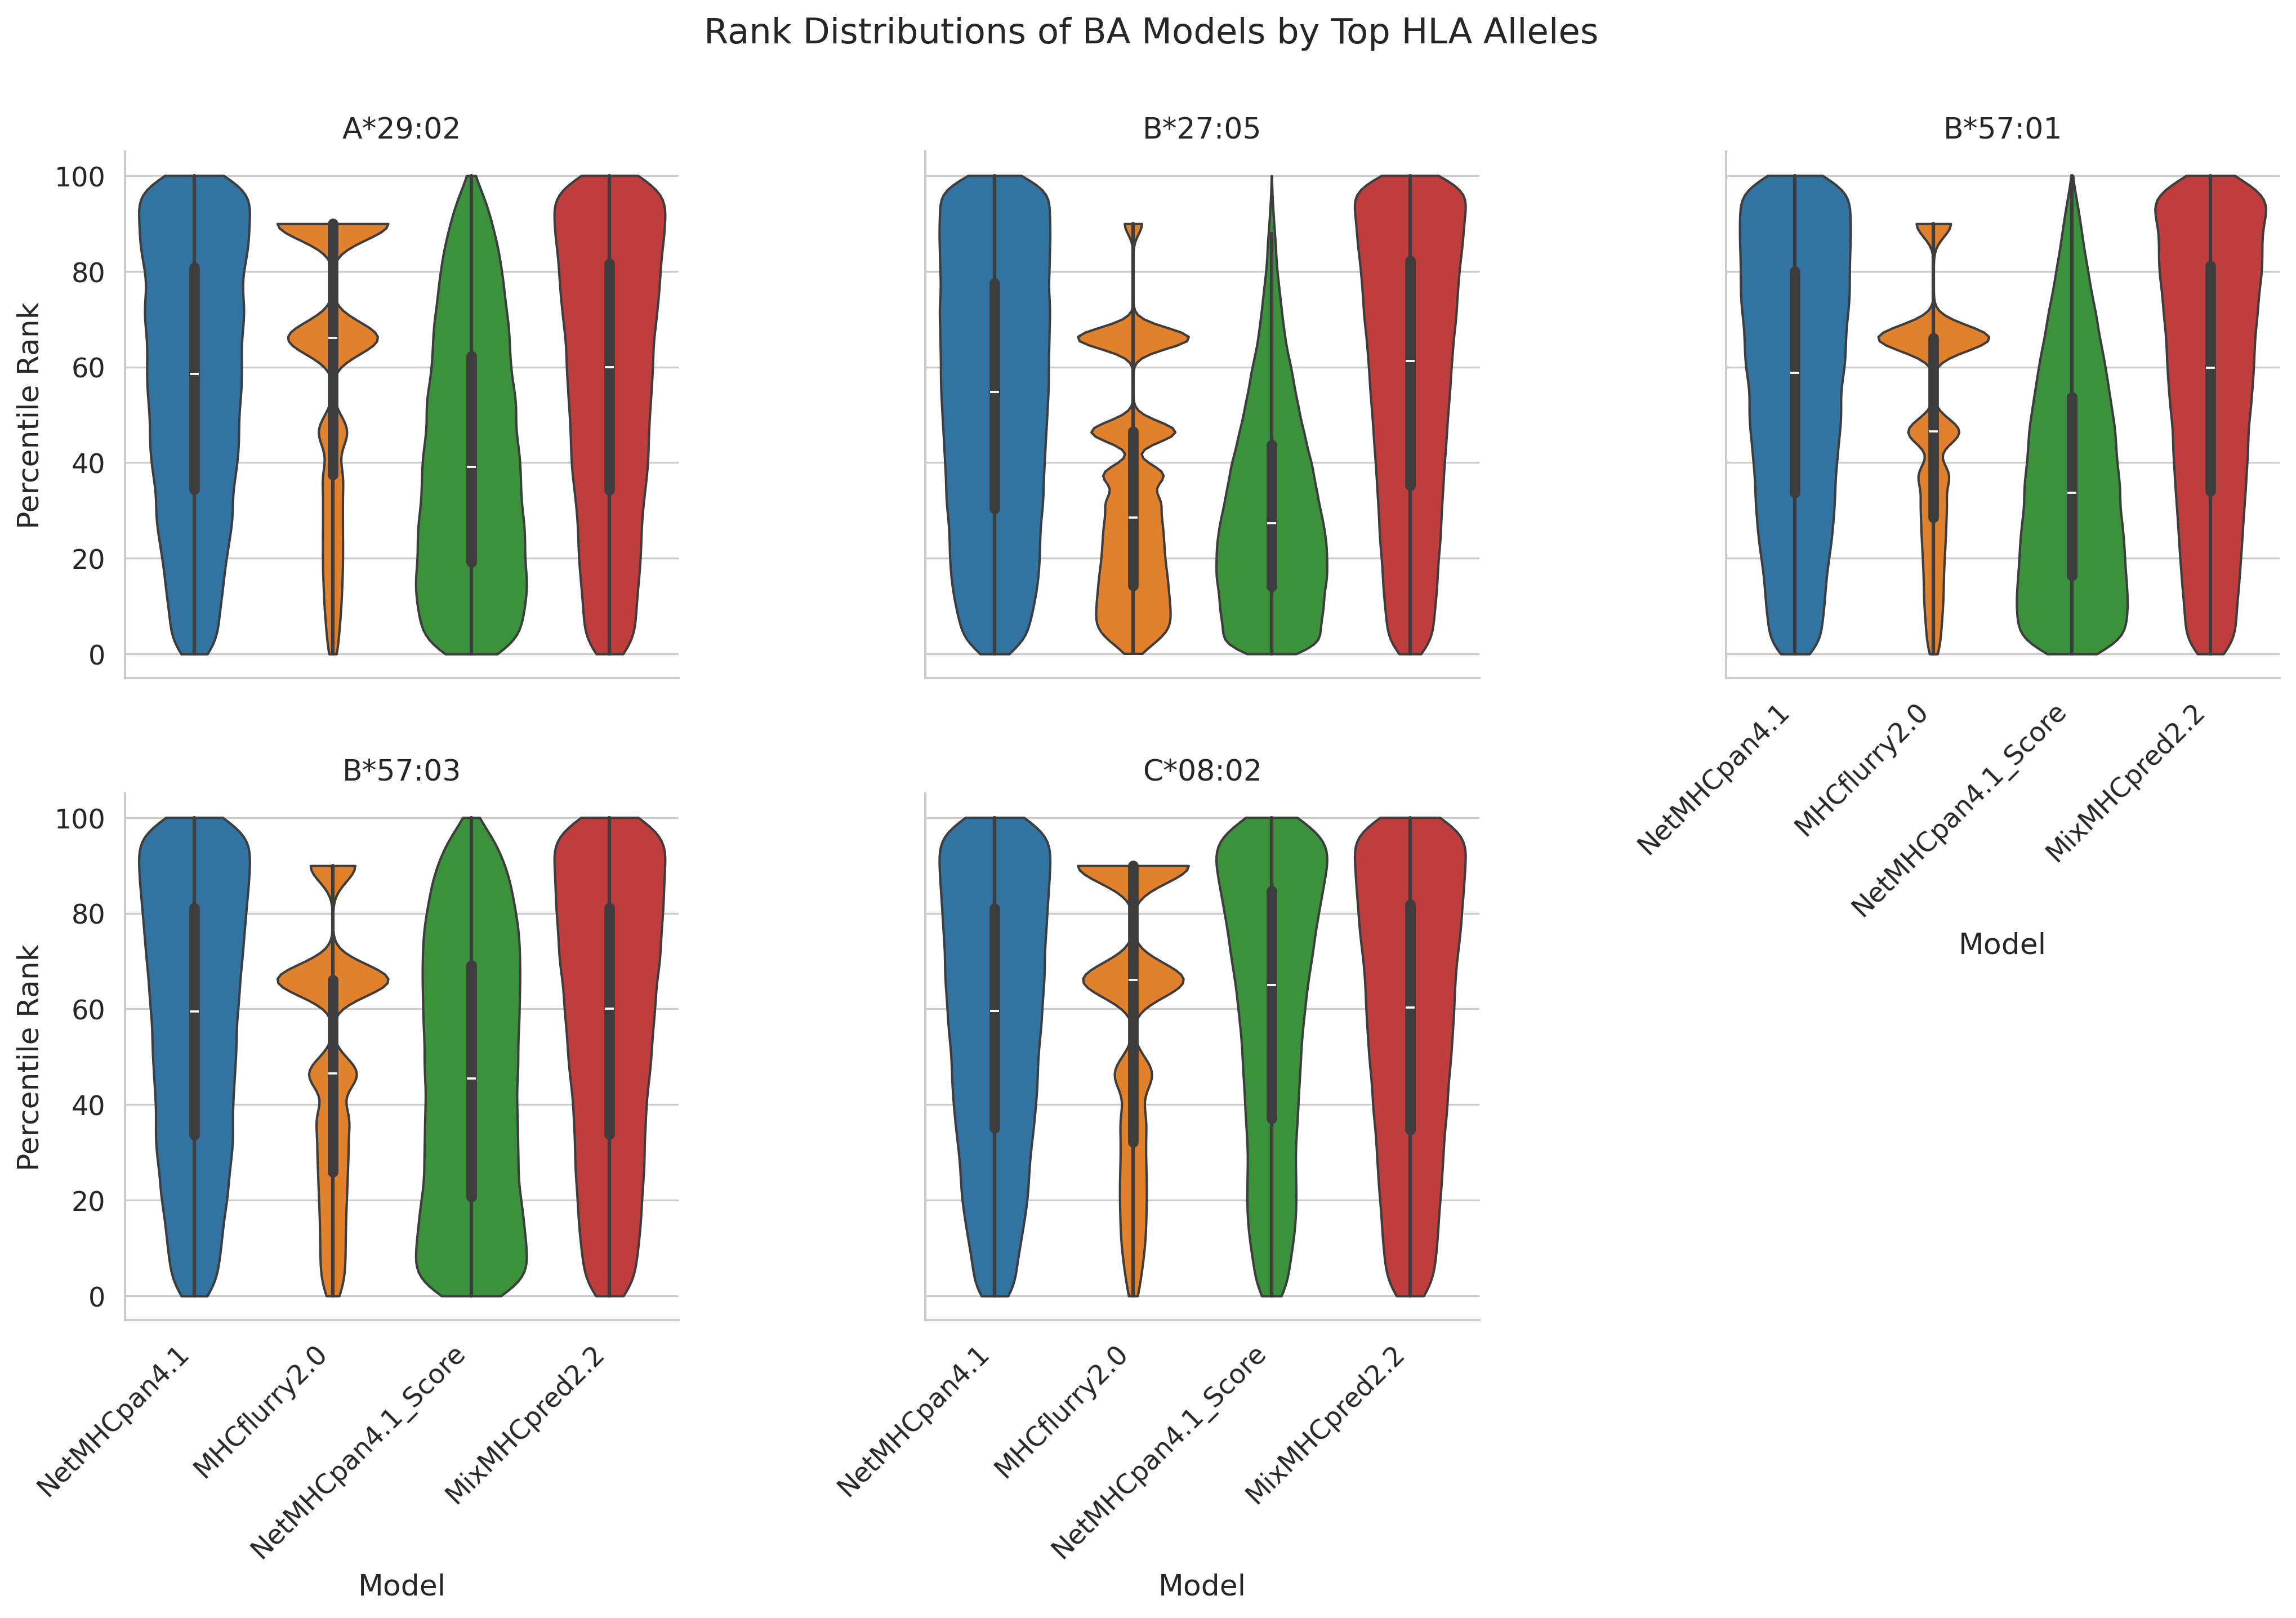

In [72]:
sns.set(style='whitegrid', context='paper', font_scale=1.3)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# Define rank columns and model names
rank_columns_normalized = [
    'NetMHCpan4.1_BA_rank_normalized',
    'MHCflurry2.0_rank_normalized',
    'NetMHCpan4.1_BA_score_rank',
    'mixmhcpred2.2_rank'
]
model_names = ['NetMHCpan4.1', 'MHCflurry2.0', 'NetMHCpan4.1_Score', 'MixMHCpred2.2']
top_alleles = ['B*27:05', 'B*57:01', 'A*29:02', 'C*08:02', 'B*57:03']

# Create violin plots
g = sns.catplot(
    data=updated_ranks_df[updated_ranks_df['allele'].isin(top_alleles)].melt(id_vars=['allele'], value_vars=rank_columns_normalized, var_name='Model', value_name='Rank'),
    x='Model', y='Rank', col='allele', kind='violin', col_wrap=3, height=4, aspect=1.2,
    palette='tab10', cut=0
)
g.set_axis_labels('Model', 'Percentile Rank')
g.set_titles('{col_name}')
g.set_xticklabels(model_names, rotation=45, ha='right')
plt.suptitle('Rank Distributions of BA Models by Top HLA Alleles', y=1.05)
plt.savefig('violin_plots_alleles_normalized.png', bbox_inches='tight')
plt.show()

Spearman Correlation Matrix:
                                  NetMHCpan4.1_BA_rank_normalized  \
NetMHCpan4.1_BA_rank_normalized                         1.000000   
MHCflurry2.0_rank_normalized                            0.463138   
NetMHCpan4.1_BA_score_rank                              0.605964   
mixmhcpred2.2_rank                                      0.628014   

                                 MHCflurry2.0_rank_normalized  \
NetMHCpan4.1_BA_rank_normalized                      0.463138   
MHCflurry2.0_rank_normalized                         1.000000   
NetMHCpan4.1_BA_score_rank                           0.282576   
mixmhcpred2.2_rank                                   0.517654   

                                 NetMHCpan4.1_BA_score_rank  \
NetMHCpan4.1_BA_rank_normalized                    0.605964   
MHCflurry2.0_rank_normalized                       0.282576   
NetMHCpan4.1_BA_score_rank                         1.000000   
mixmhcpred2.2_rank                                 

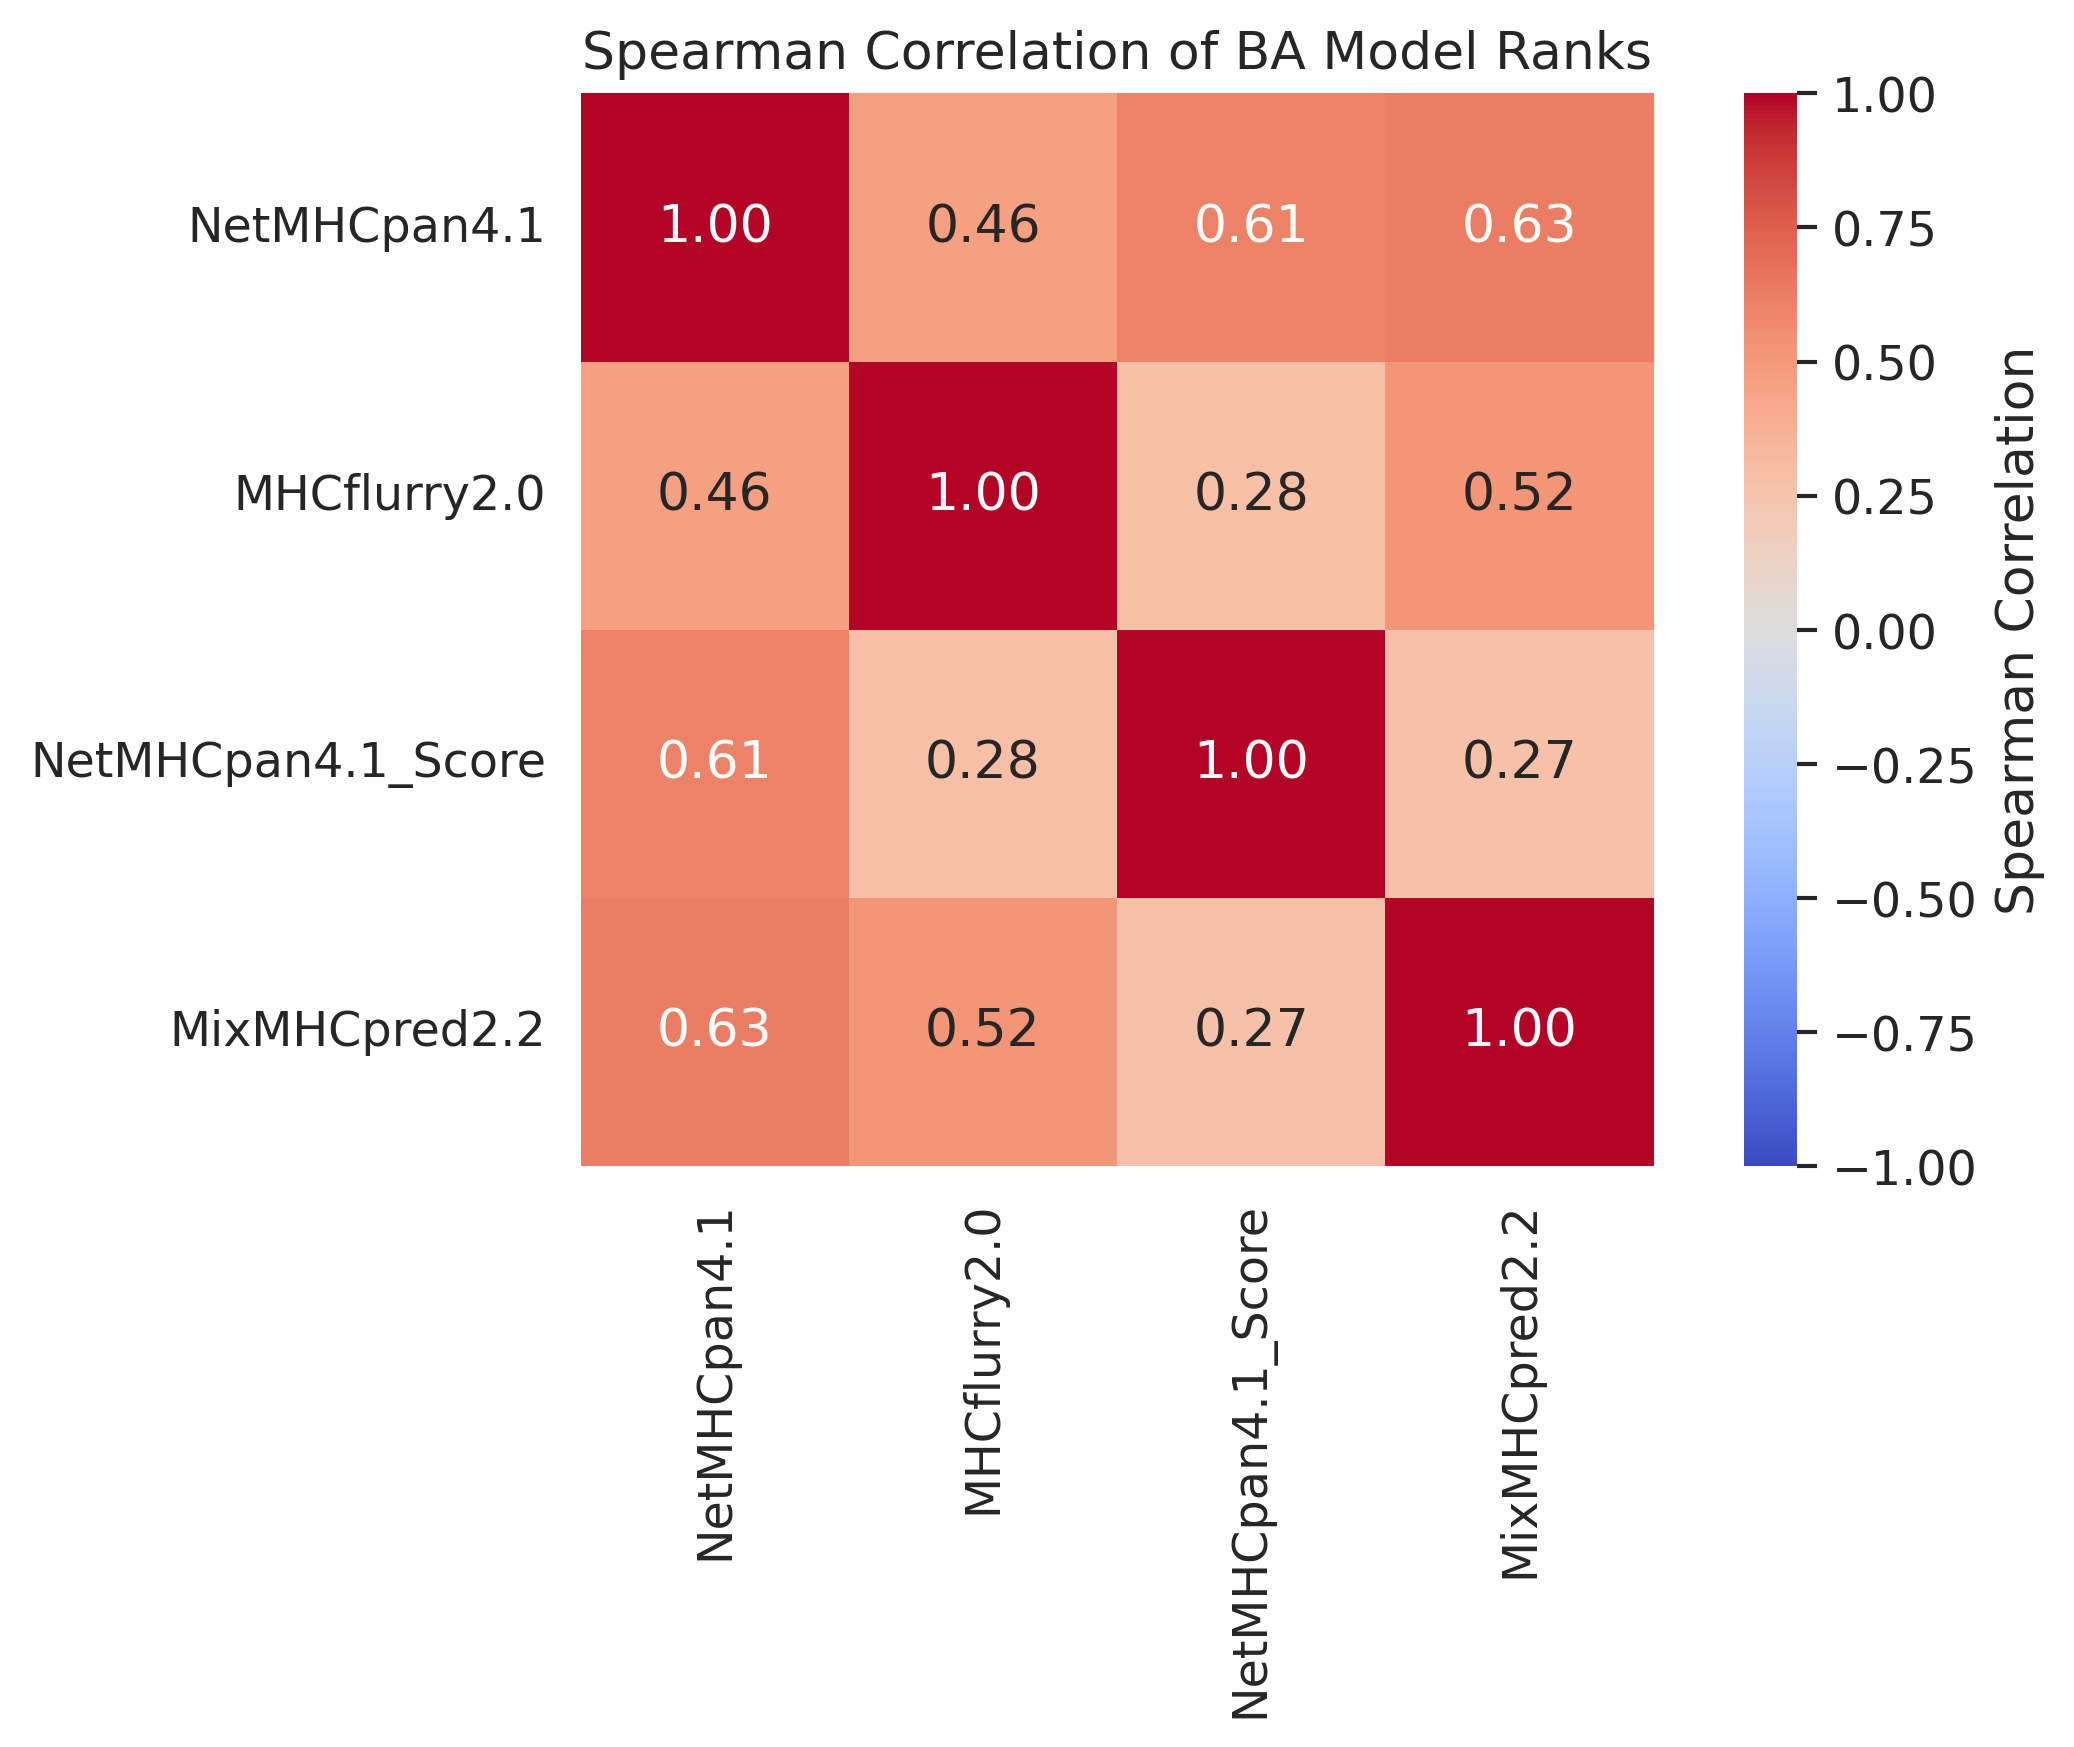

In [73]:
sns.set(style='whitegrid', context='paper', font_scale=1.3)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# Define rank columns and model names
rank_columns_normalized = [
    'NetMHCpan4.1_BA_rank_normalized',
    'MHCflurry2.0_rank_normalized',
    'NetMHCpan4.1_BA_score_rank',
    'mixmhcpred2.2_rank'
]
model_names = ['NetMHCpan4.1', 'MHCflurry2.0', 'NetMHCpan4.1_Score', 'MixMHCpred2.2']

# Compute Spearman correlation matrix
corr_matrix = updated_ranks_df[rank_columns_normalized].corr(method='spearman')

# Print correlation matrix for reference
print("Spearman Correlation Matrix:\n", corr_matrix)

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1, center=0,
    fmt='.2f',
    xticklabels=model_names,
    yticklabels=model_names,
    square=True,
    cbar_kws={'label': 'Spearman Correlation'}
)
plt.title('Spearman Correlation of BA Model Ranks')
plt.tight_layout()
plt.savefig('spearman_heatmap_normalized.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_25629/1585550390.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


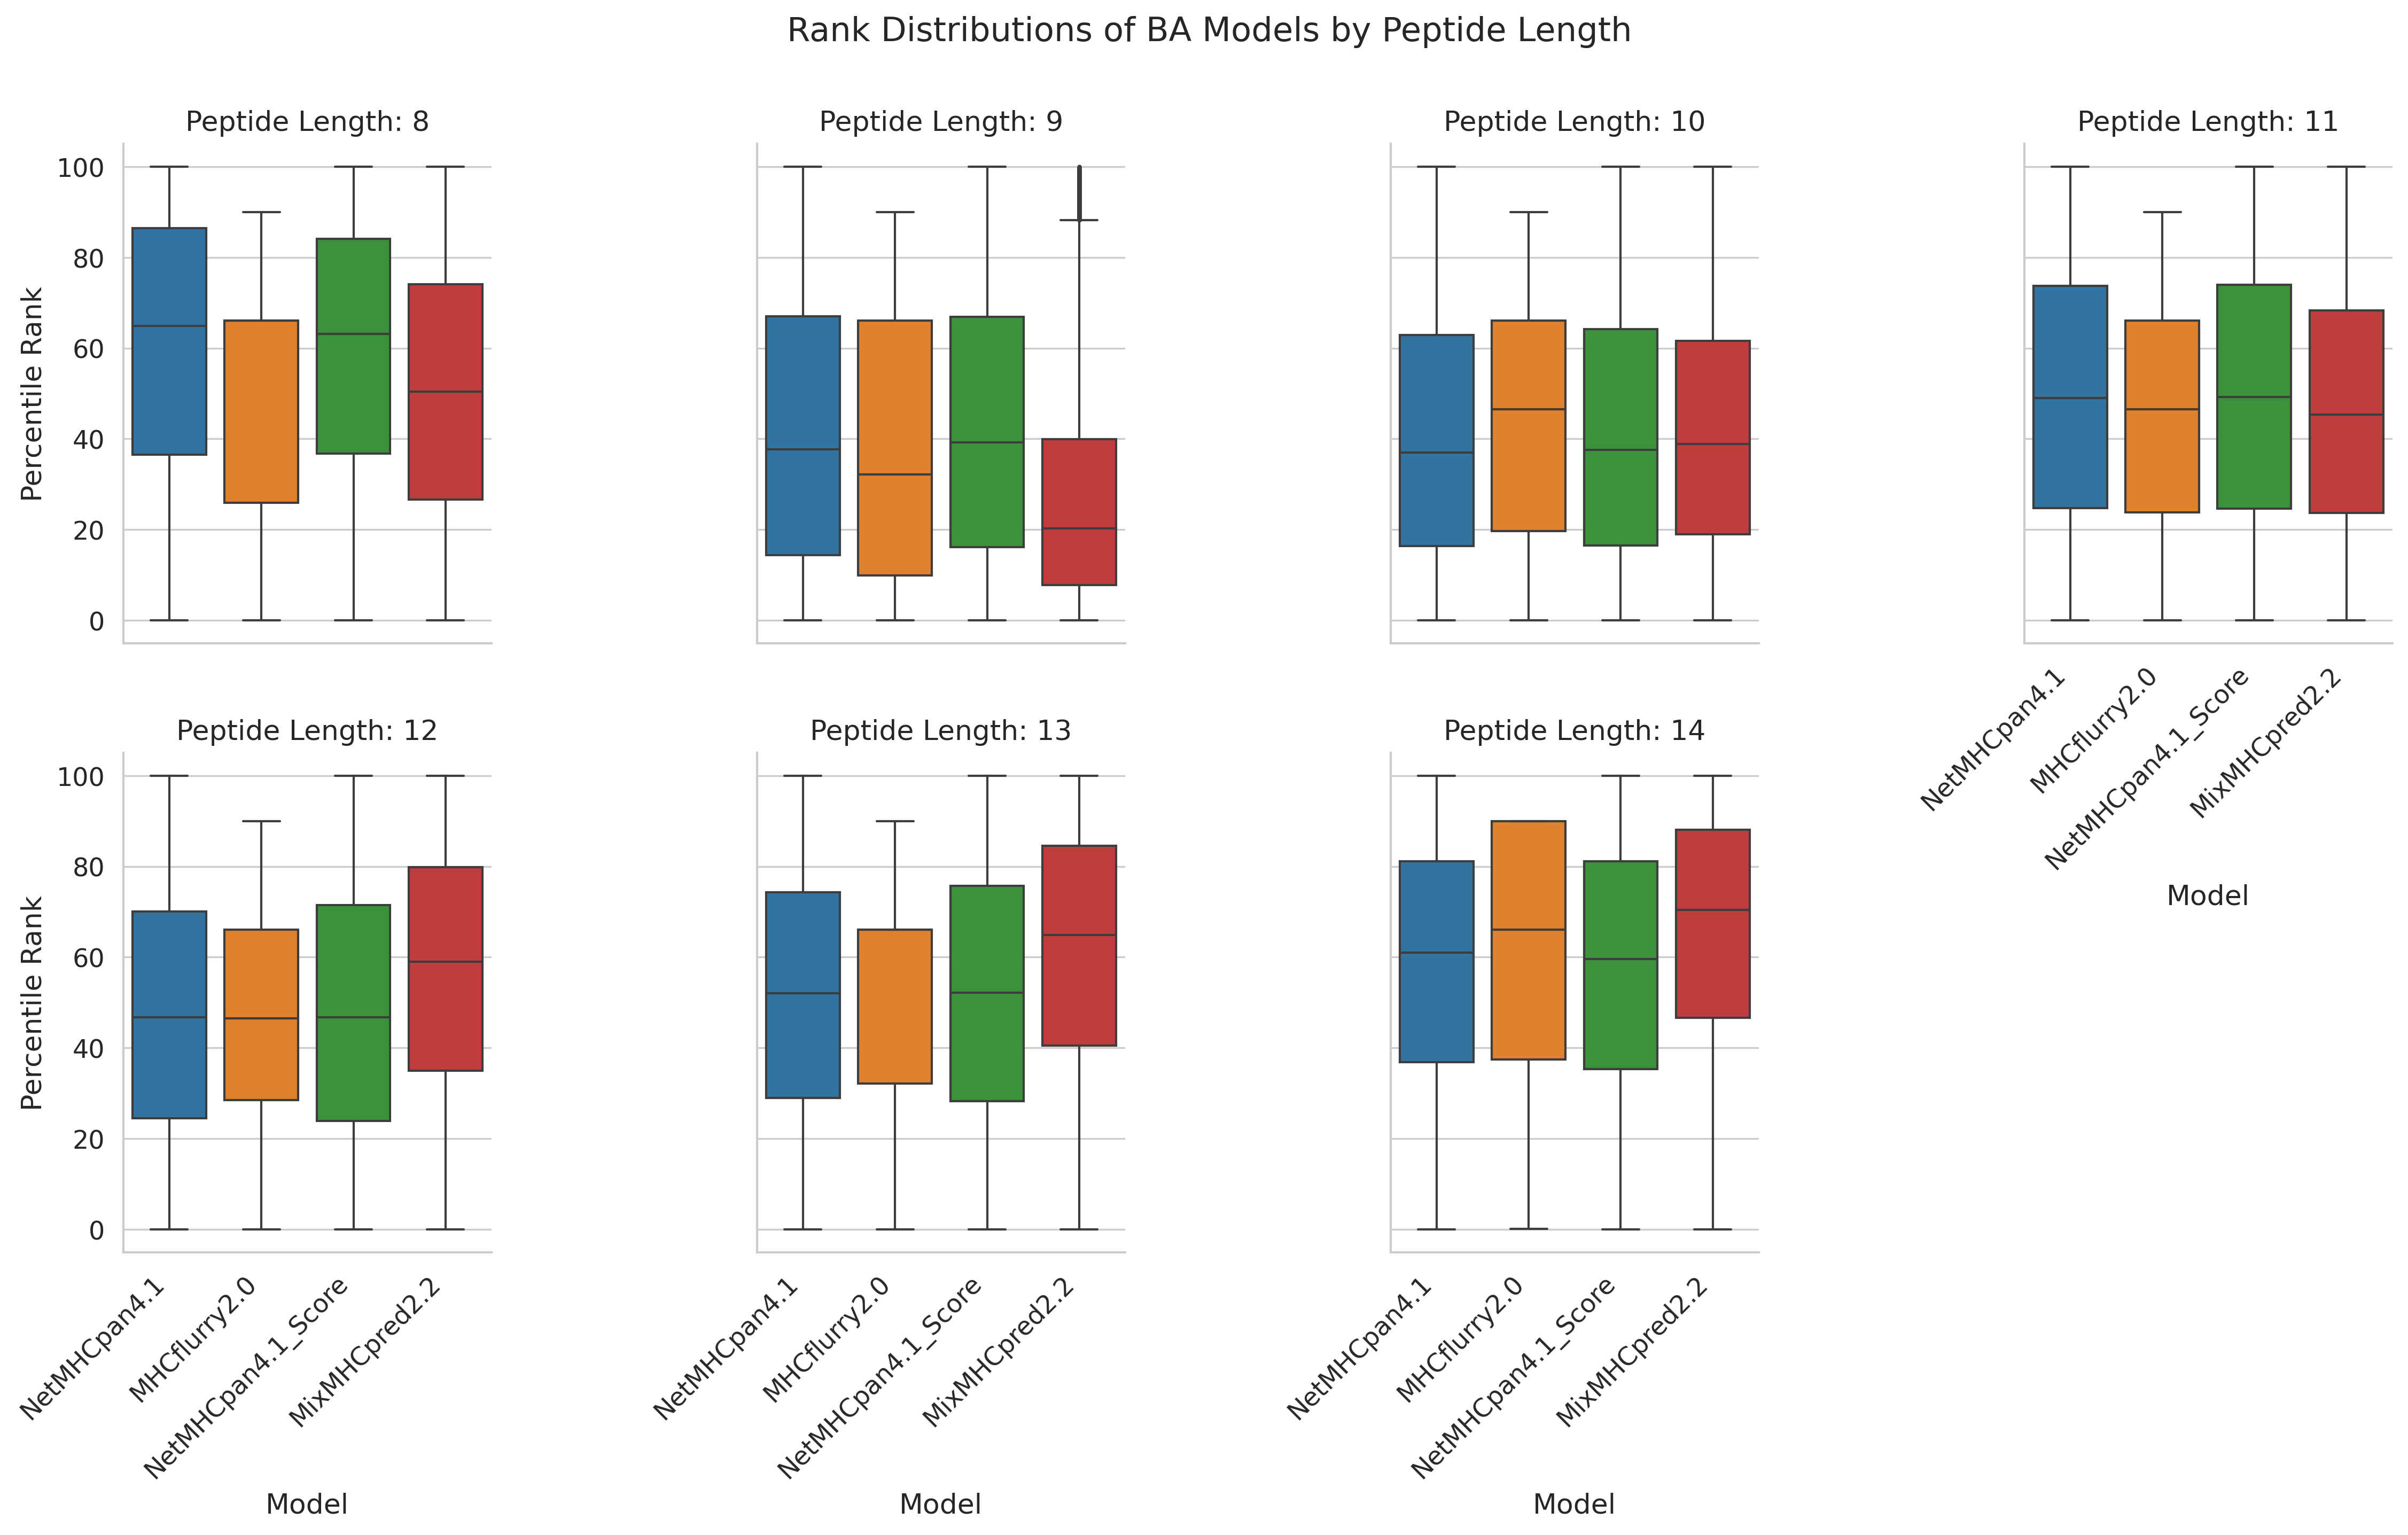

In [74]:
sns.set(style='whitegrid', context='paper', font_scale=1.3)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# Define rank columns and model names
rank_columns_normalized = [
    'NetMHCpan4.1_BA_rank_normalized',
    'MHCflurry2.0_rank_normalized',
    'NetMHCpan4.1_BA_score_rank',
    'mixmhcpred2.2_rank'
]
model_names = ['NetMHCpan4.1', 'MHCflurry2.0', 'NetMHCpan4.1_Score', 'MixMHCpred2.2']

# Create box plots by peptide length
g = sns.catplot(
    data=updated_ranks_df.melt(id_vars=['peptide_length'], value_vars=rank_columns_normalized, var_name='Model', value_name='Rank'),
    x='Model', y='Rank', col='peptide_length', col_wrap=4, kind='box', height=4, aspect=1,
    palette='tab10', fliersize=1, linewidth=1
)
g.set_axis_labels('Model', 'Percentile Rank')
g.set_titles('Peptide Length: {col_name}')
g.set_xticklabels(model_names, rotation=45, ha='right')
plt.suptitle('Rank Distributions of BA Models by Peptide Length', y=1.05)
plt.savefig('rank_by_peptide_length_normalized.png', bbox_inches='tight')
plt.show()

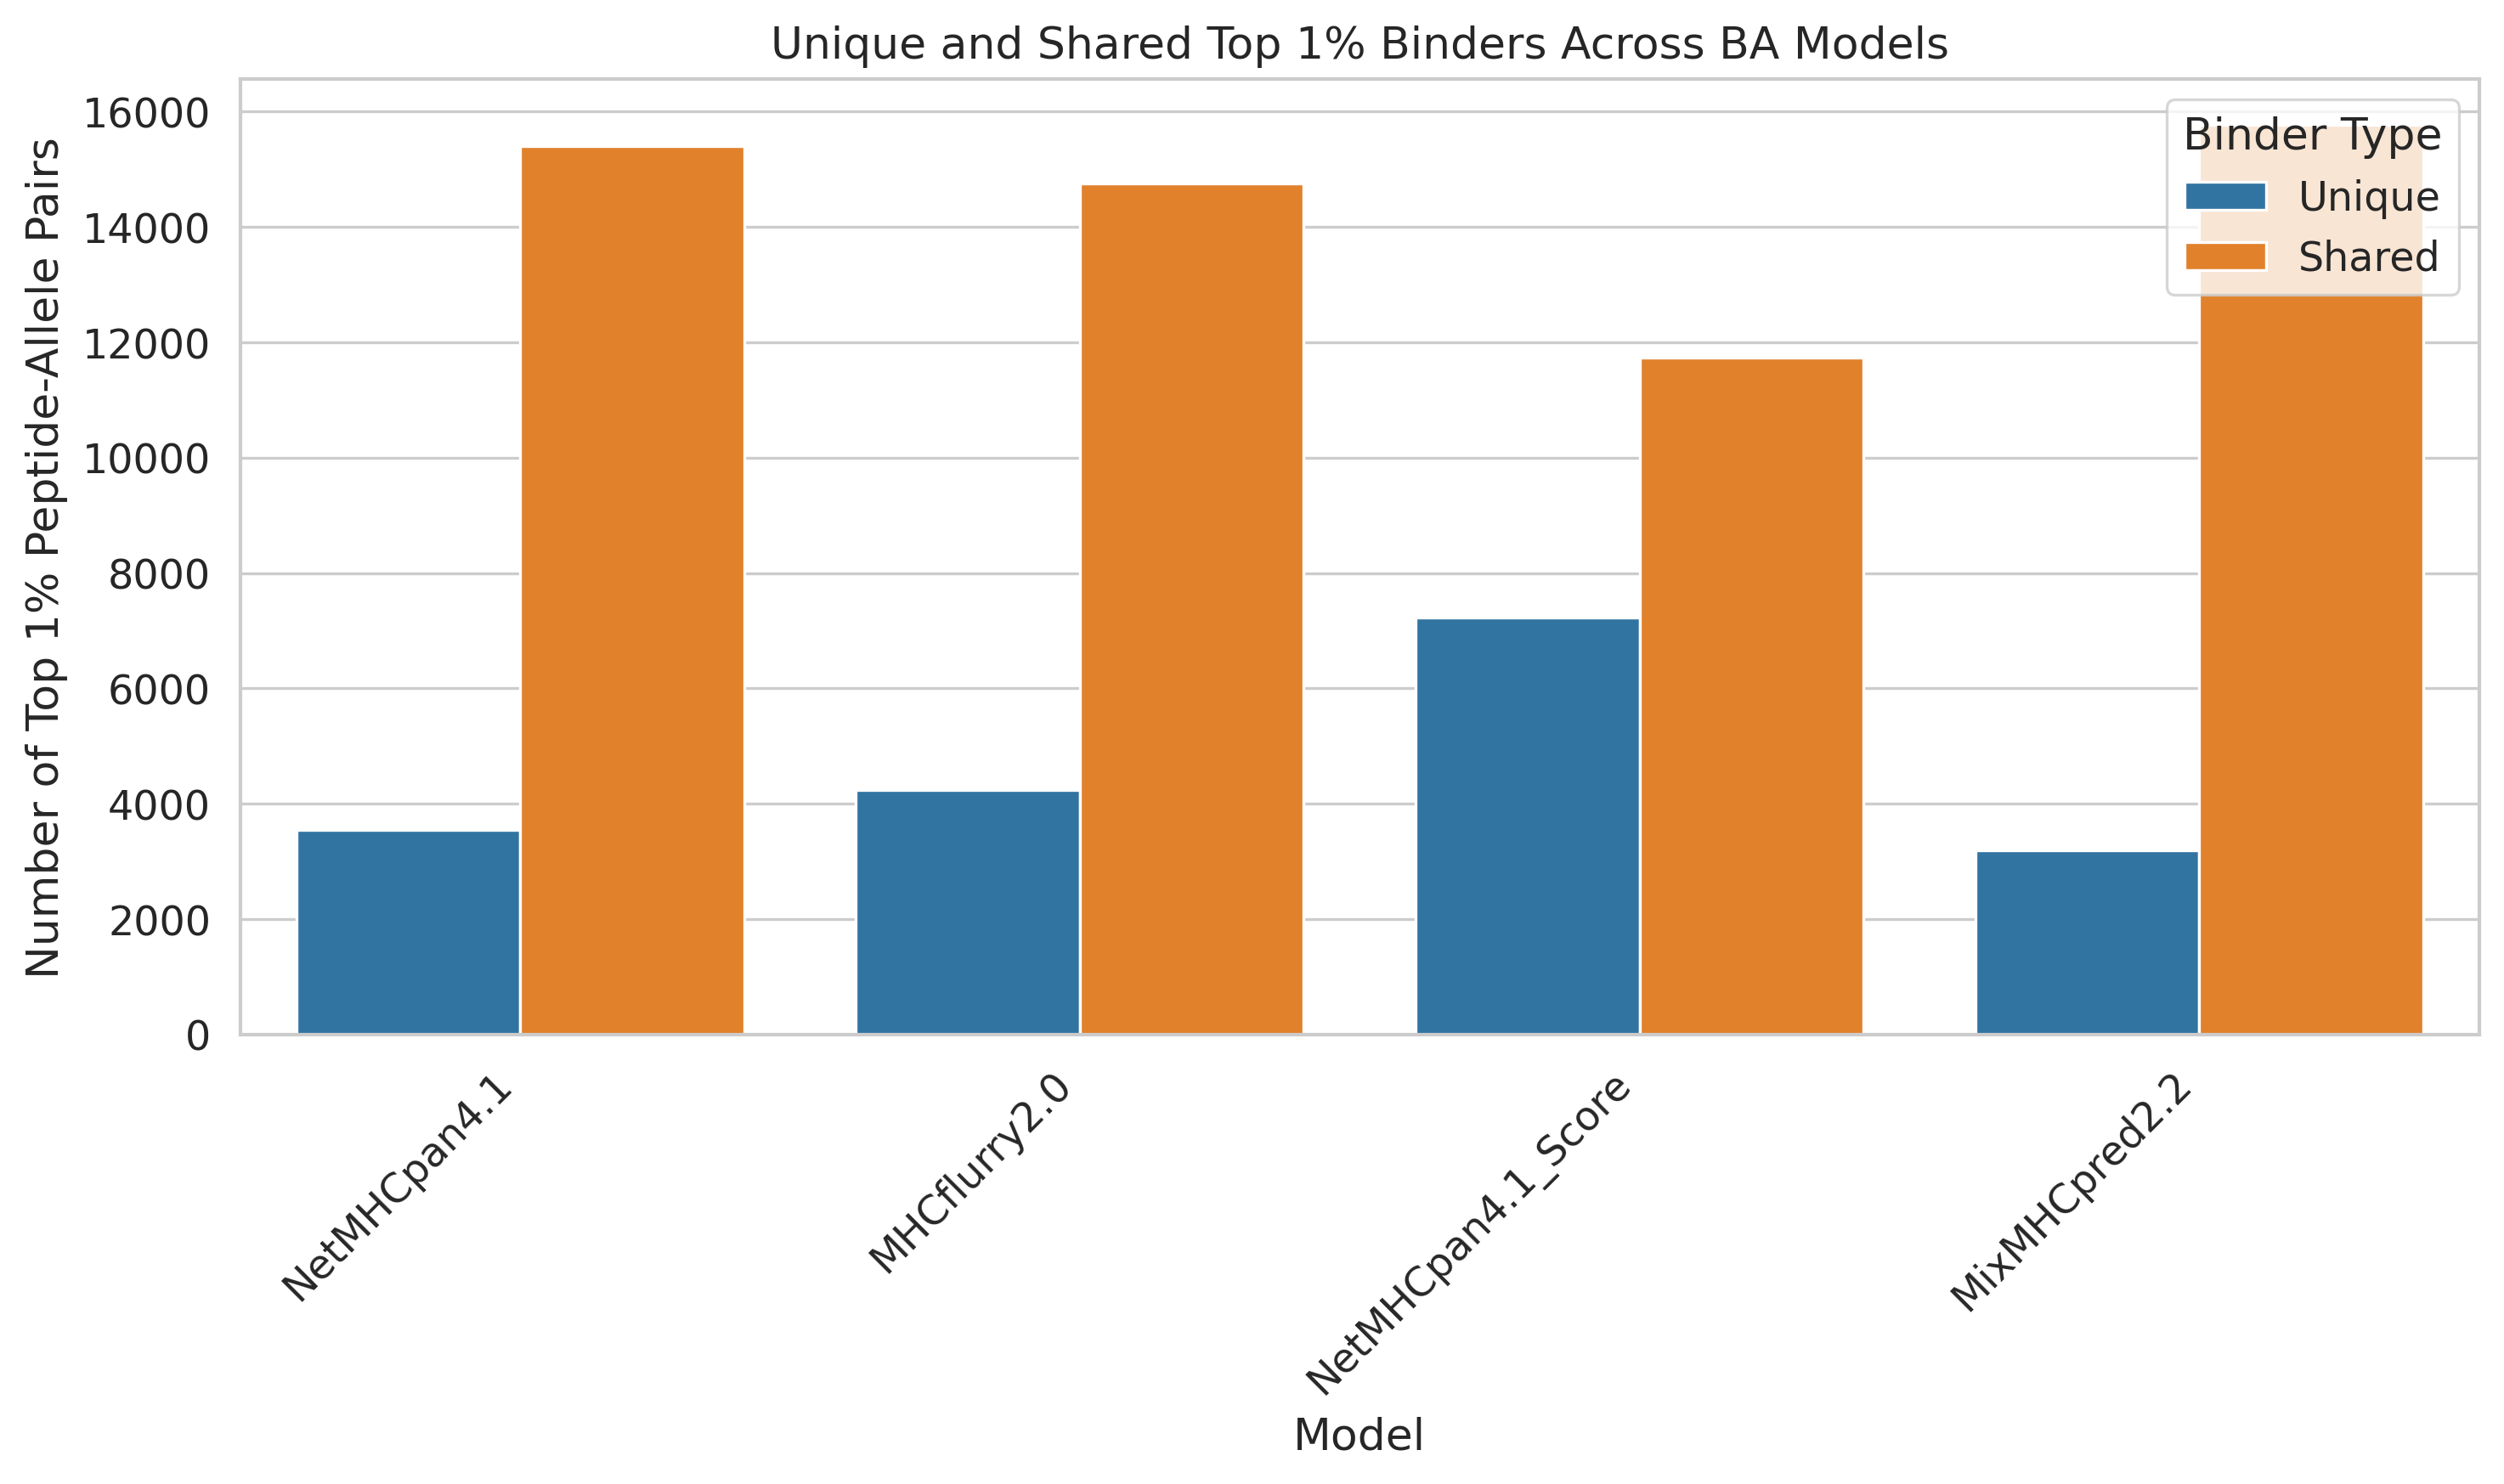


Jaccard Similarity for Top 1% Binders:
                     NetMHCpan4.1  MHCflurry2.0  NetMHCpan4.1_Score  \
NetMHCpan4.1            1.000000      0.405801            0.320506   
MHCflurry2.0            0.405801      1.000000            0.275397   
NetMHCpan4.1_Score      0.320506      0.275397            1.000000   
MixMHCpred2.2           0.466752      0.480534            0.293115   

                    MixMHCpred2.2  
NetMHCpan4.1             0.466752  
MHCflurry2.0             0.480534  
NetMHCpan4.1_Score       0.293115  
MixMHCpred2.2            1.000000  


In [75]:
sns.set(style='whitegrid', context='paper', font_scale=1.3)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

# Define rank columns and model names
rank_columns_normalized = [
    'NetMHCpan4.1_BA_rank_normalized',
    'MHCflurry2.0_rank_normalized',
    'NetMHCpan4.1_BA_score_rank',
    'mixmhcpred2.2_rank'
]
model_names = ['NetMHCpan4.1', 'MHCflurry2.0', 'NetMHCpan4.1_Score', 'MixMHCpred2.2']

# Identify top 1% binders
top_binder_sets = {
    col: set(updated_ranks_df[updated_ranks_df[col] < 1][['allele', 'peptide']].apply(tuple, axis=1))
    for col in rank_columns_normalized
}

# Compute unique and shared binders for each model
overlap_data = []
for i, col in enumerate(rank_columns_normalized):
    model = model_names[i]
    unique = top_binder_sets[col] - set.union(*(s for j, s in enumerate(top_binder_sets.values()) if j != i))
    shared = top_binder_sets[col] & set.union(*(s for j, s in enumerate(top_binder_sets.values()) if j != i))
    overlap_data.append({
        'Model': model,
        'Unique': len(unique),
        'Shared': len(shared)
    })

# Create dataframe for plotting
overlap_df = pd.DataFrame(overlap_data).melt(id_vars='Model', value_vars=['Unique', 'Shared'], var_name='Type', value_name='Count')

# Create stacked bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=overlap_df, x='Model', y='Count', hue='Type', palette='tab10')
plt.xlabel('Model')
plt.ylabel('Number of Top 1% Peptide-Allele Pairs')
plt.title('Unique and Shared Top 1% Binders Across BA Models')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Binder Type')
plt.tight_layout()
plt.savefig('top_binder_overlap_stacked_normalized.png', bbox_inches='tight')
plt.show()

# Compute Jaccard similarity table
jaccard = np.zeros((len(rank_columns_normalized), len(rank_columns_normalized)))
for i, col1 in enumerate(rank_columns_normalized):
    for j, col2 in enumerate(rank_columns_normalized):
        intersection = len(top_binder_sets[col1] & top_binder_sets[col2])
        union = len(top_binder_sets[col1] | top_binder_sets[col2])
        jaccard[i, j] = intersection / union if union > 0 else 0
jaccard_df = pd.DataFrame(jaccard, index=model_names, columns=model_names)
print("\nJaccard Similarity for Top 1% Binders:\n", jaccard_df)

Missing values in filtered_el_df:
 allele                        0
peptide                       0
HLApollo                      0
NetMHCpan4.1_EL_score         0
NetMHCpan4.1_EL_rank          0
TransPHLA                     0
HLAthena                 847938
FFNN                          0
bigmhc                        0
dtype: int64
Total missing values: 847938
Rows in filtered_el_df: 1895999
Unique alleles: 211

Rows in filtered_el_df_clean: 1895999
Missing values in filtered_el_df_clean:
 allele                   0
peptide                  0
HLApollo                 0
NetMHCpan4.1_EL_score    0
NetMHCpan4.1_EL_rank     0
TransPHLA                0
FFNN                     0
bigmhc                   0
dtype: int64

HLApollo value counts (top 10):
 HLApollo
-41.205025    10
-42.095604    10
-40.427025    10
-42.098960    10
-42.568703     9
-42.177025     9
-42.174736     9
-42.672720     9
-42.384743     9
-43.057350     9
Name: count, dtype: int64

NetMHCpan4.1_EL_score value counts

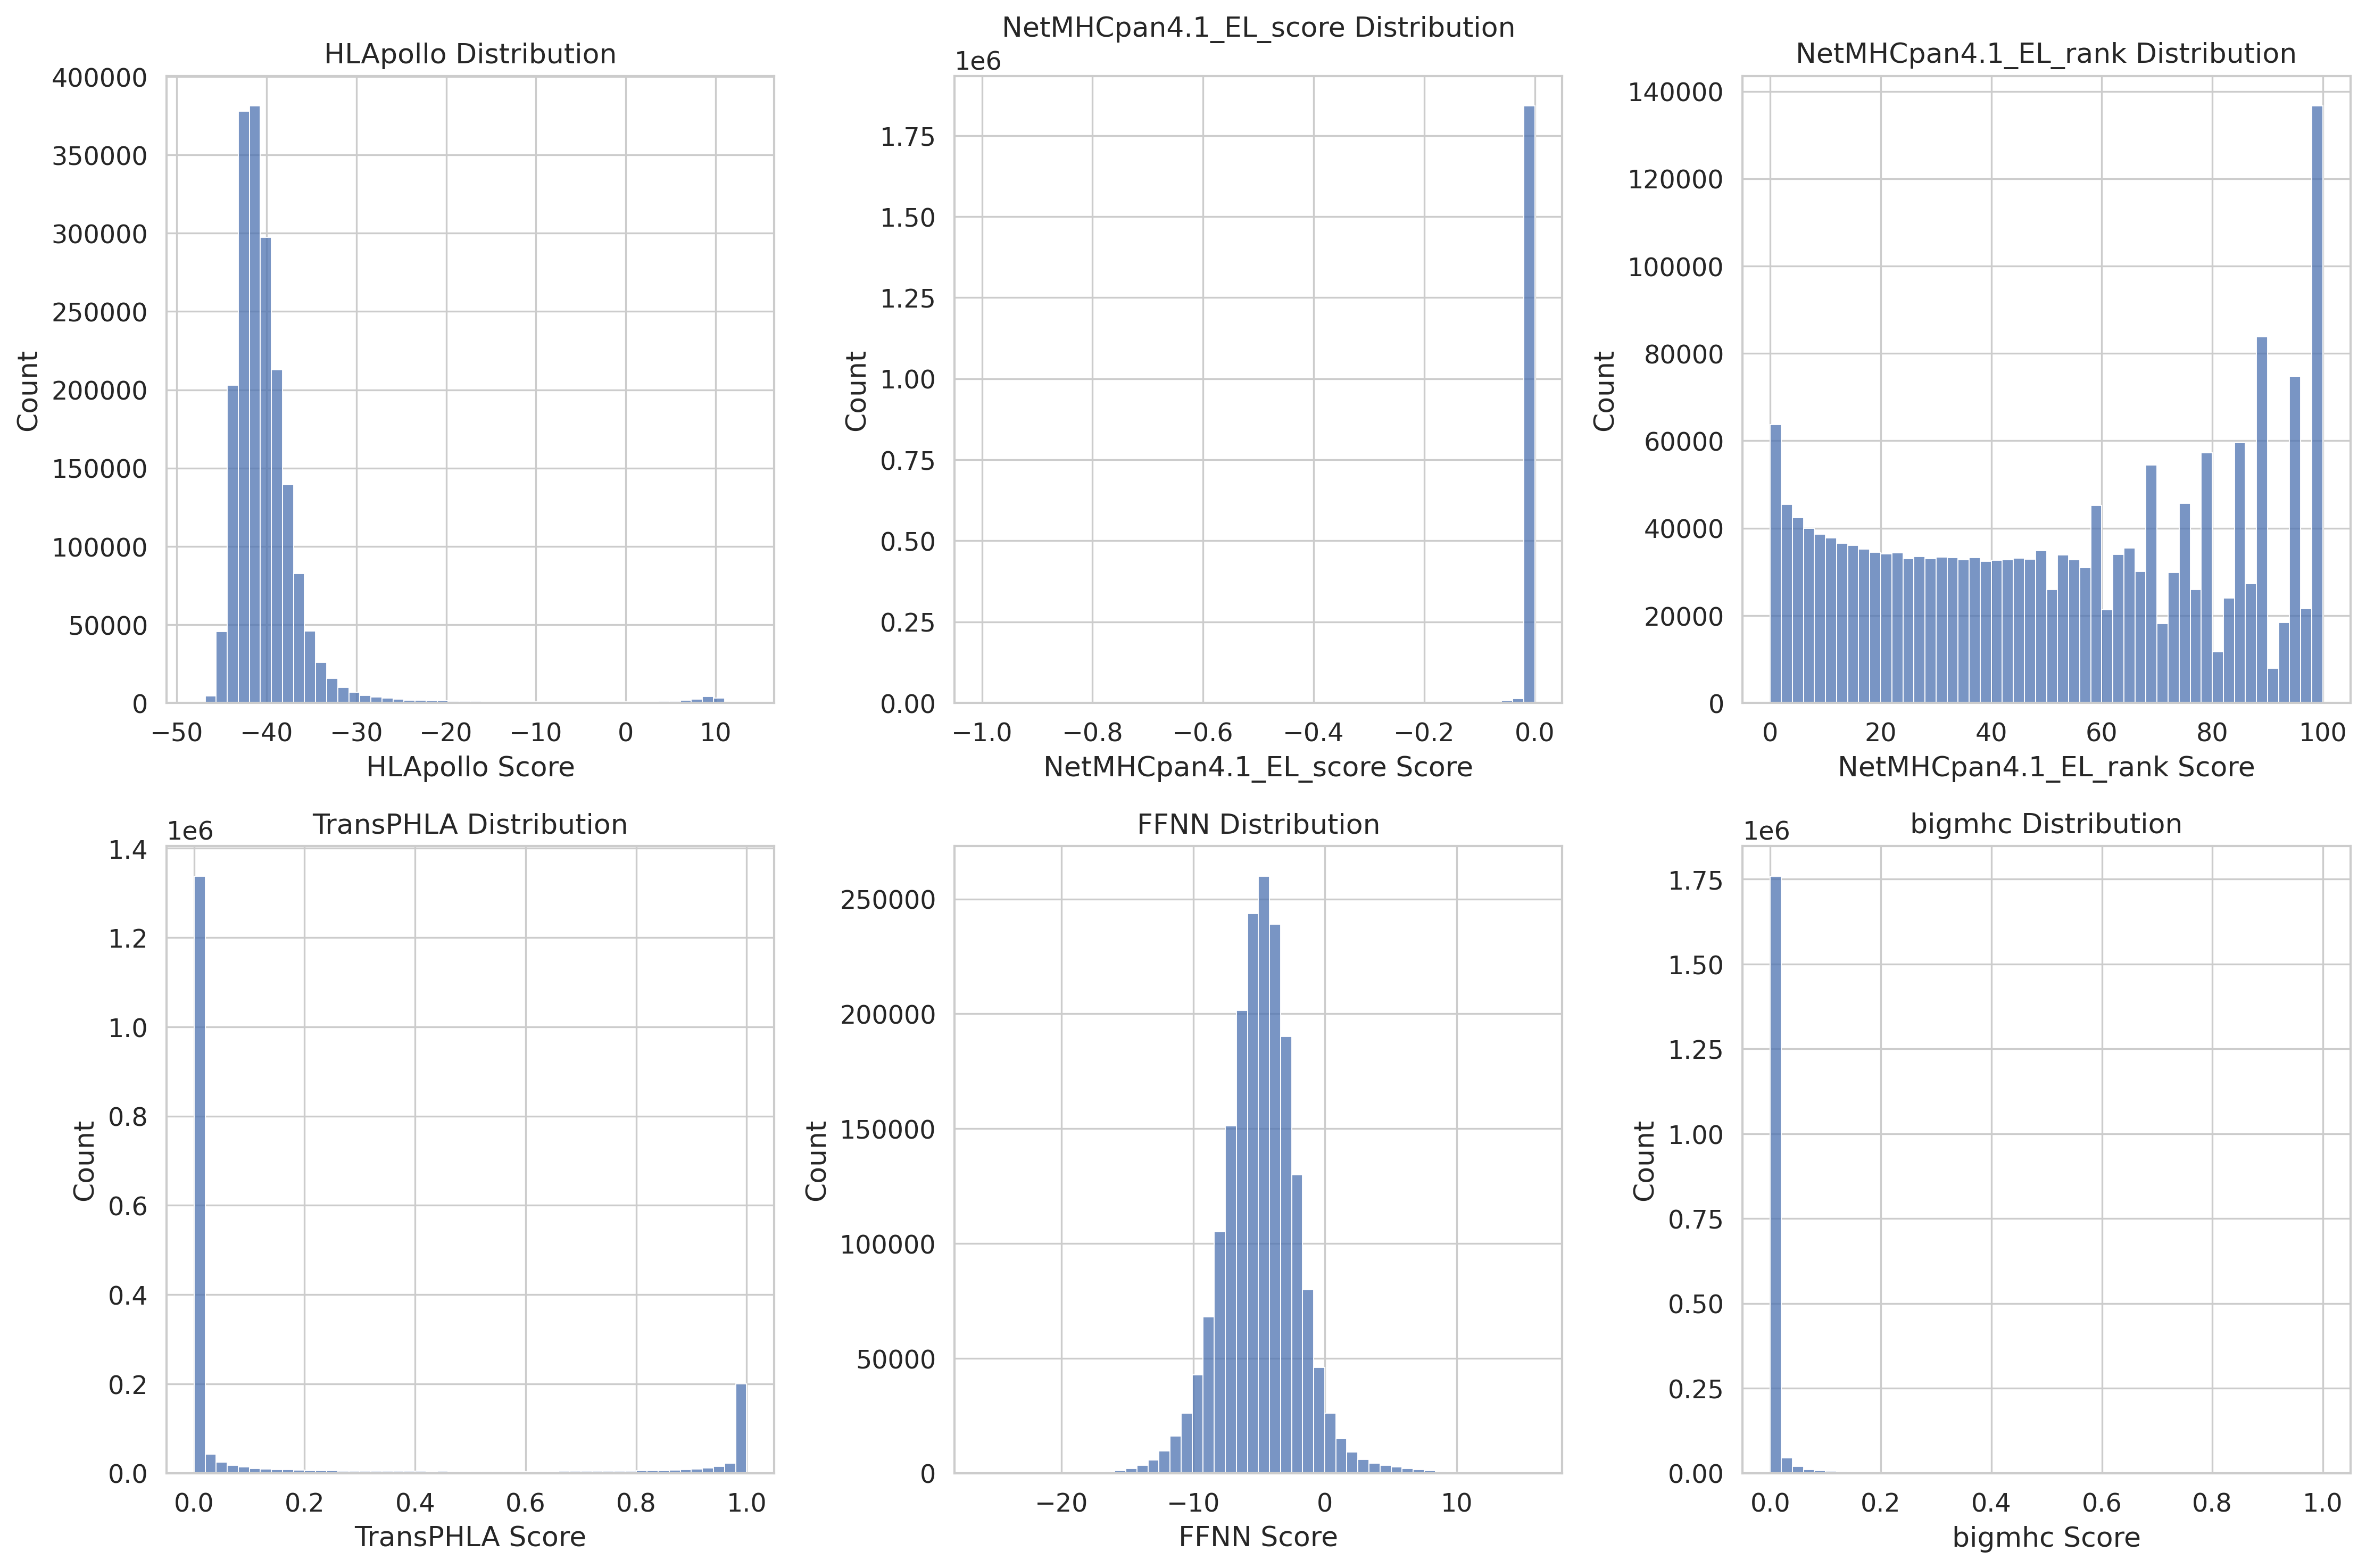


Number of top 1% binders per EL model:
HLApollo_rank: 18959
NetMHCpan4.1_EL_score_rank: 18961
NetMHCpan4.1_EL_rank_normalized: 18962
TransPHLA_rank: 71880
FFNN_rank: 18959
bigmhc_rank: 18959

Summary statistics for EL rank columns:
       HLApollo_rank  NetMHCpan4.1_EL_score_rank  \
count   1.895999e+06                1.895999e+06   
mean    5.000003e+01                2.607198e+01   
std     2.886752e+01                9.246221e+00   
min     5.274264e-05                5.274264e-05   
25%     2.500005e+01                2.146119e+01   
50%     5.000003e+01                3.177997e+01   
75%     7.500001e+01                3.177997e+01   
max     1.000000e+02                3.177997e+01   

       NetMHCpan4.1_EL_rank_normalized  TransPHLA_rank     FFNN_rank  \
count                     1.895999e+06    1.895999e+06  1.895999e+06   
mean                      4.949484e+01    3.752943e+01  5.000003e+01   
std                       2.823478e+01    1.642749e+01  2.886752e+01   
min       

In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Check missing values in filtered_el_df
print("Missing values in filtered_el_df:\n", filtered_el_df.isna().sum())
print("Total missing values:", filtered_el_df.isna().sum().sum())
print("Rows in filtered_el_df:", len(filtered_el_df))
print("Unique alleles:", filtered_el_df['allele'].nunique())

# Exclude HLAthena, keep all rows
el_model_columns = ['HLApollo', 'NetMHCpan4.1_EL_score', 'NetMHCpan4.1_EL_rank', 'TransPHLA', 'FFNN', 'bigmhc']
filtered_el_df_clean = filtered_el_df[['allele', 'peptide'] + el_model_columns].copy()
print("\nRows in filtered_el_df_clean:", len(filtered_el_df_clean))
print("Missing values in filtered_el_df_clean:\n", filtered_el_df_clean.isna().sum())

# Check distributions for all EL model columns
for col in el_model_columns:
    print(f"\n{col} value counts (top 10):\n", filtered_el_df_clean[col].value_counts().head(10))

# Plot distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(el_model_columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(filtered_el_df_clean[col], bins=50)
    plt.xlabel(f'{col} Score')
    plt.ylabel('Count')
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

# Create updated_el_ranks_df
updated_el_ranks_df = filtered_el_df_clean[['allele', 'peptide']].copy()
updated_el_ranks_df['peptide_length'] = updated_el_ranks_df['peptide'].str.len()

# Function to compute percentile ranks
def compute_percentile_ranks(series, ascending=True, method='average'):
    non_na_series = series.dropna()
    ranks = non_na_series.rank(ascending=ascending, method=method)
    percentile_ranks = (ranks / len(non_na_series)) * 100
    return percentile_ranks.reindex(series.index)

# Rank and normalize EL model outputs
# Lower is better: HLApollo (logit), NetMHCpan4.1_EL_score (likelihood), NetMHCpan4.1_EL_rank (rank), FFNN (score)
# Higher is better: TransPHLA (probability), bigmhc (probability)
updated_el_ranks_df['HLApollo_rank'] = compute_percentile_ranks(filtered_el_df_clean['HLApollo'], ascending=True, method='average')
updated_el_ranks_df['NetMHCpan4.1_EL_score_rank'] = compute_percentile_ranks(filtered_el_df_clean['NetMHCpan4.1_EL_score'], ascending=True, method='min')  # Handle ties
updated_el_ranks_df['NetMHCpan4.1_EL_rank_normalized'] = compute_percentile_ranks(filtered_el_df_clean['NetMHCpan4.1_EL_rank'], ascending=True, method='min')  # Handle ties
updated_el_ranks_df['TransPHLA_rank'] = compute_percentile_ranks(filtered_el_df_clean['TransPHLA'], ascending=False, method='min')  # Higher is better, handle ties
updated_el_ranks_df['FFNN_rank'] = compute_percentile_ranks(filtered_el_df_clean['FFNN'], ascending=True, method='average')
updated_el_ranks_df['bigmhc_rank'] = compute_percentile_ranks(filtered_el_df_clean['bigmhc'], ascending=False, method='average')

# Verify top 1% binder counts
el_rank_columns = [
    'HLApollo_rank',
    'NetMHCpan4.1_EL_score_rank',
    'NetMHCpan4.1_EL_rank_normalized',
    'TransPHLA_rank',
    'FFNN_rank',
    'bigmhc_rank'
]
print("\nNumber of top 1% binders per EL model:")
for col in el_rank_columns:
    count = len(updated_el_ranks_df[updated_el_ranks_df[col] < 1])
    print(f"{col}: {count}")

# Summary statistics for ranks
print("\nSummary statistics for EL rank columns:")
print(updated_el_ranks_df[el_rank_columns].describe())

# Save the updated dataframe
updated_el_ranks_df.to_csv('updated_el_ranks_no_hlathena.csv', index=False)

# Display first 5 rows
print("\nUpdated EL Ranks Dataframe (first 5 rows):")
print(updated_el_ranks_df.head())